<a href="https://colab.research.google.com/github/outlook1227/Python-Notebook-for-Dataset/blob/main/Credit%20Card%20Risk%20(Nova%20Bank)/Credit_Card_Risk_at_Nova_Bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Basic Libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import warnings
warnings.filterwarnings('ignore')

# Statistical Analysis
from scipy.stats import chi2_contingency, mannwhitneyu, ks_2samp

# Machine Learning Libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer, RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve,
                            brier_score_loss, log_loss, precision_recall_curve, average_precision_score)
from sklearn.metrics import precision_recall_curve, auc as auc_calculations
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV, calibration_curve

# Advanced Model
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

# Imbalance Learning
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# Create churn valuation framework
from dataclasses import dataclass
from collections import defaultdict

# Model Interpretation
import shap

# Configurations
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Runtime control
FAST_MODE = True
print("All Python libraries have been imported!")
print("Ready for data analysis and machine learning tasks.")
print(f"Fast run is {'Enabled' if FAST_MODE else 'disabled'}")
print("RANDOM_STATE:", RANDOM_STATE)

All Python libraries have been imported!
Ready for data analysis and machine learning tasks.
Fast run is Enabled
RANDOM_STATE: 42


# 1. EDA - Exploratory Data Analysis

In [2]:
print("=" * 10, "DATASET OVERVIEW" ,"=" * 10)

# Read data
df = pd.read_excel("/content/drive/MyDrive/Credit Card Approval/Risk Data/Credit Risk Dataset.xlsx")

# Data information
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage().sum() / 1024 ** 2:.2f} MB")
print(f"Duplicated rows: {df.duplicated().sum()}")

# Data type
print("\nData types distribution:")
print(df.dtypes.value_counts())

# Review Data
print("\nFirst few rows of the dataset:")
display(df.head())

# Display full of column names
print("Total number of columns:", len(df.columns))
cols_str = ", ".join(f'"{c}"' for c in df.columns)
df_wrapped = textwrap.fill(cols_str, width=220)
print(f"Column names: [{df_wrapped}]")

# Normalize column names to lowercase
df.columns = df.columns.str.lower()
print("\nColumn names have been normalized to lowercase.")

========== DATASET OVERVIEW ==========
Dataset shape: (32581, 29)
Memory usage: 7.21 MB
Duplicated rows: 0

Data types distribution:
object     12
float64     9
int64       8
Name: count, dtype: int64

First few rows of the dataset:


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


Total number of columns: 29
Column names: ["client_ID", "person_age", "person_income", "person_home_ownership", "person_emp_length", "loan_intent", "loan_grade", "loan_amnt", "loan_int_rate", "loan_status", "loan_percent_income", "cb_person_default_on_file",
"cb_person_cred_hist_length", "gender", "marital_status", "education_level", "country", "state", "city", "city_latitude", "city_longitude", "employment_type", "loan_term_months", "loan_to_income_ratio", "other_debt",
"debt_to_income_ratio", "open_accounts", "credit_utilization_ratio", "past_delinquencies"]

Column names have been normalized to lowercase.


========== TARGET VARIABLE CREATION ==========
Target variables: loan_status
Bad Distribution: 
             count
loan_status       
0            25473
1             7108
Overall Bad Rate: 0.2182 (21.82%))


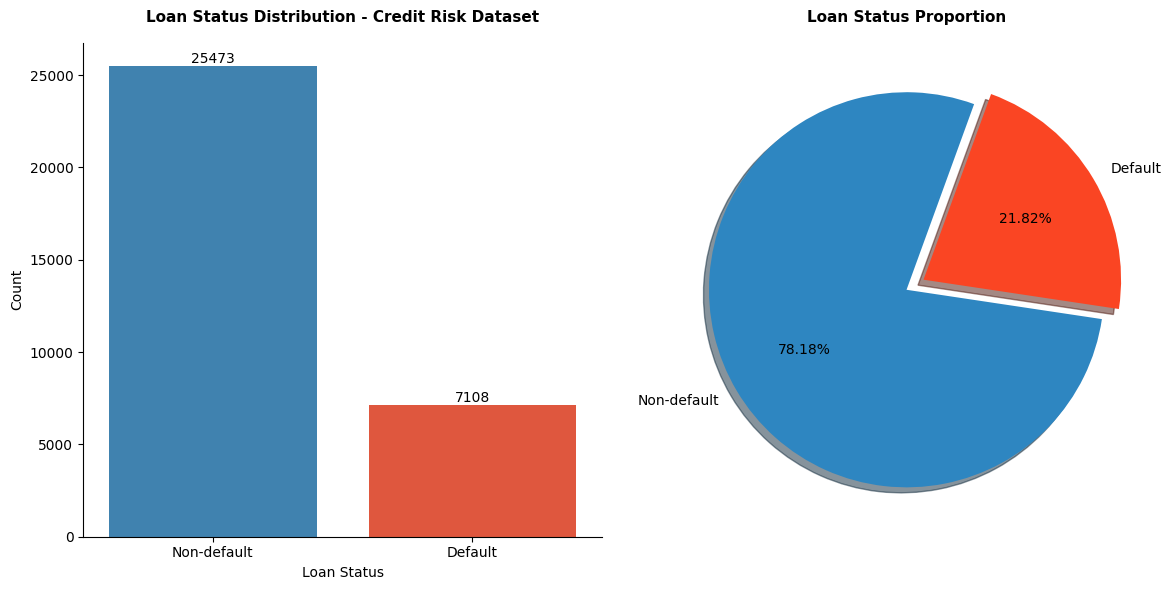

In [3]:
print("=" * 10, "TARGET VARIABLE CREATION" ,"=" *10)

target_features = "loan_status"

# Target variables analysis (Risk = 1, No risk = 0)
# Directly using df[target_features] for value counts, as loan_status is already 0/1
target_counts = df[target_features].value_counts()

if 1 in target_counts.index:
    bad_rate = (target_counts[1] / (target_counts[0] + target_counts[1]))
else:
    bad_rate = 0.0
    print("No bad customers found in the dataset.")

print("Target variables:", target_features)
print("Bad Distribution: ")
print(pd.DataFrame(target_counts))
print(f"Overall Bad Rate: {bad_rate:.4f} ({bad_rate * 100:.2f}%))")

# Initialize a figure with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Define colors and labels for consistency across plots
colors_plot = ['#2e86c1', '#fa4523'] # Blue for non-default, Red for default
labels_map = {0: "Non-default", 1: "Default"}
order_labels = [0, 1] # Ensure consistent order

# Plot 1: Countplot
sns.countplot(data=df, x=target_features, palette=colors_plot,
              ax=ax[0], order=order_labels)
ax[0].set_title(f"Loan Status Distribution - Credit Risk Dataset", weight="bold", fontsize=11, pad=15)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%d", label_type="edge", fontsize=10)
ax[0].set_ylabel("Count")
ax[0].set_xlabel("Loan Status")
ax[0].set_xticklabels([labels_map[0], labels_map[1]]) # Set meaningful labels
sns.despine(ax=ax[0], top=True, right=True, left=False, bottom=False)

# Plot 2: Pie Chart
df[target_features].value_counts().plot.pie(
    explode=[0, 0.10],
    autopct='%1.2f%%',
    ax=ax[1], # Corrected: Use ax[1] for the second plot
    shadow=True,
    colors=colors_plot,
    labels=[labels_map[0], labels_map[1]], # Use meaningful labels
    fontsize=10,
    startangle=70)
ax[1].set_title("Loan Status Proportion", weight="bold", fontsize=11, pad=15) # Add a title
ax[1].set_ylabel("") # Remove default 'loan_status' ylabel
plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

In [4]:
print("=" * 10, "DATA QUALITY SUMMARY", "=" * 10)

# Missing values analysis in dataset
print("1. Assessment")
missing_values = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Missing_count" : df.isnull().sum(),
    "Missing_percentage" : (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()})

print("Missing values summary:")
check_cols = missing_values[missing_values["Missing_percentage"] > 0]
if len(check_cols) > 0:
  print(check_cols.head(20))
else:
  print("No missing values")

print("\n2. Suspicious checking values")
suspicious_values = False
for col in df.select_dtypes(include=['object']).columns:
    suspicious_vals = ['?', 'unknown', 'null', '', 'n/a', 'na']
    for val in suspicious_vals:
        count = df[col].astype(str).str.lower().eq(val.lower()).sum()
        if count > 0:
            print(f"{col}: '{val}' appears {count} times")
            suspicious_values = True

if not suspicious_values:
    print("✓ No suspicious values detected")

total_missing = df.isnull().sum().sum() # Sum the Series to get a single value
total_percent = (total_missing / df.size) * 100 # Calculate the overall percentage
print(f"\n🔍 Total missing cells: {total_missing:,} ({total_percent:.2f}% of all data)")
print("\n","=" * 10, "DATA QUALITY CHECK COMPLETED", "=" * 10)

========== DATA QUALITY SUMMARY ==========
1. Assessment
Missing values summary:
                  Data Type  Non-Null Count  Missing_count  \
person_emp_length   float64           31686            895   
loan_int_rate       float64           29465           3116   

                   Missing_percentage  Unique Values  
person_emp_length                2.75             36  
loan_int_rate                    9.56            348  

2. Suspicious checking values
✓ No suspicious values detected

🔍 Total missing cells: 4,011 (0.42% of all data)

 ========== DATA QUALITY CHECK COMPLETED ==========


In [5]:
print("=" * 10, "FEATURE CATEGORIZATIONS","=" * 10)

# Define featured group based on business logic
features_group = {
    "demographic" : ["person_age", "gender", "marital_status", "education_level"],
    "employment" : ["employment_type", "person_emp_length", "person_income"],
    "loan": ["loan_intent", "loan_grade", "loan_amnt", "loan_int_rate", "loan_term_months", "loan_percent_income"],
    "financial": ["loan_to_income_ratio", "debt_to_income_ratio", "other_debt", "credit_utilization_ratio"],
    "credit_history": ["cb_person_default_on_file", "cb_person_cred_hist_length", "past_delinquencies", "open_accounts"],
    "housing": ["person_home_ownership"],
    "geographic": ["country", "state", "city","city_latitude","city_longitude"]
}

# Identify available features
available_features = {}
total_features = 0

for feature_group, feature_list in features_group.items():
  available = [f for f in feature_list if f in df.columns]
  available_features[feature_group] = available
  total_features += len(available)

  print(f"\n{feature_group.upper()} ({len(available)}/{len(feature_list)}):")
  if available:
    print(f"Available: {available}")

  missing = [f for f in feature_list if f not in df.columns]
  if missing:
    print(f"Missing: {missing}")
print(f"\nTotal available features: {total_features}")

========== FEATURE CATEGORIZATIONS ==========

DEMOGRAPHIC (4/4):
Available: ['person_age', 'gender', 'marital_status', 'education_level']

EMPLOYMENT (3/3):
Available: ['employment_type', 'person_emp_length', 'person_income']

LOAN (6/6):
Available: ['loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_term_months', 'loan_percent_income']

FINANCIAL (4/4):
Available: ['loan_to_income_ratio', 'debt_to_income_ratio', 'other_debt', 'credit_utilization_ratio']

CREDIT_HISTORY (4/4):
Available: ['cb_person_default_on_file', 'cb_person_cred_hist_length', 'past_delinquencies', 'open_accounts']

HOUSING (1/1):
Available: ['person_home_ownership']

GEOGRAPHIC (5/5):
Available: ['country', 'state', 'city', 'city_latitude', 'city_longitude']

Total available features: 27


In [6]:
print("=" * 10, "DATA VALIDATION", "=" * 10)

# Find features to remove
constant_features = [col for col in df.columns if df[col].nunique() <= 1]
high_missing_features = [col for col in df.columns if df[col].isnull().mean() > 0.8]
features_to_remove = list(set(constant_features + high_missing_features))

print(f"Constant features: {len(constant_features)}")
print(f"High missing features: {len(high_missing_features)}")
print(f"Total features to remove: {len(features_to_remove)}")

# Remove features
original_shape = df.shape
df = df.drop(columns=features_to_remove, errors="ignore")
print(f"Shape: {original_shape} → {df.shape}")

# ==== FEAUTRE PREPARATIONS ====
# Create modeling features from available-features
modeling_features = []
for feature_group, feature_names_list in available_features.items():
  modeling_features.extend(feature_names_list)

# Remove the duplicates. These features have not survived.
modeling_features = list(dict.fromkeys(modeling_features))
modeling_features = [col for col in modeling_features if col in df.columns]

# Classify for type of data
categorical_features = [f for f in modeling_features if f in df.select_dtypes(include=["object"]).columns]
numerical_features = [f for f in modeling_features if f in df.select_dtypes(include=[np.number]).columns]

# Result
print("\nFinal Features")
print(f" Categorical features: {len(categorical_features)}")
print(f" Numerical features: {len(numerical_features)}")
print(f" Total features: {len(modeling_features)}")

# Save the data
MODELING_FEATURES = modeling_features
CATEGORICAL_FEATURES = categorical_features
NUMERIC_FEATURES = numerical_features

========== DATA VALIDATION ==========
Constant features: 0
High missing features: 0
Total features to remove: 0
Shape: (32581, 29) → (32581, 29)

Final Features
 Categorical features: 11
 Numerical features: 16
 Total features: 27


========== FEATURE CORRELATION ANALYSIS ==========

Top features correlated with target:
loan_to_income_ratio          0.322292
loan_int_rate                 0.320062
loan_percent_income           0.316115
debt_to_income_ratio          0.283694
person_income                 0.272131
other_debt                    0.203782
person_emp_length             0.097558
loan_amnt                     0.084032
person_age                    0.033354
cb_person_cred_hist_length    0.023779
Name: loan_status, dtype: float64


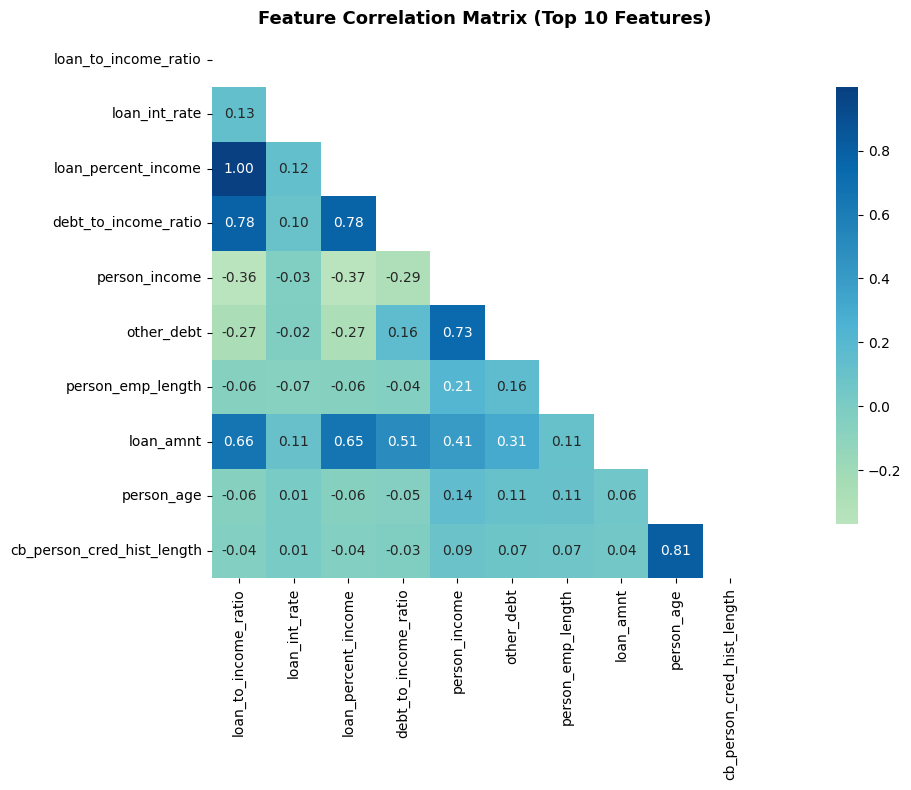


⚠ High correlation pairs (>|0.8|):
  loan_to_income_ratio ↔ loan_percent_income: 0.999
  person_age ↔ cb_person_cred_hist_length: 0.806

Top predictive features stored for later modeling:
['loan_to_income_ratio', 'loan_int_rate', 'loan_percent_income', 'debt_to_income_ratio', 'person_income', 'other_debt', 'person_emp_length', 'loan_amnt', 'person_age', 'cb_person_cred_hist_length', 'loan_term_months', 'credit_utilization_ratio', 'city_longitude', 'open_accounts', 'past_delinquencies', 'city_latitude']
========== CORRELATION ANALYSIS COMPLETED ==========


In [7]:
print("=" * 10, "FEATURE CORRELATION ANALYSIS", "=" * 10)

# 1️⃣ Remove ID column if exists
ID_COLUMNS = ["id", "ID", "customer_id", "account_id", "client_id"]
df_model = df.drop(columns=[c for c in ID_COLUMNS if c in df.columns])

# 2️⃣ Select numeric features
numeric_for_correlation = [f for f in NUMERIC_FEATURES if f in df_model.columns]

if len(numeric_for_correlation) > 0:

    # ===============================
    # 3️⃣ Correlation with target
    # ===============================

    # Ensure target_features is not duplicated in the list for correlation calculation
    features_to_correlate = [f for f in numeric_for_correlation if f != target_features]
    features_to_correlate.append(target_features)

    # Calculate correlations and explicitly ensure it's a Series before sorting
    correlations = (
        df_model[features_to_correlate]
        .corr(method="spearman")[target_features]
        .abs()
    )
    correlations = pd.Series(correlations).sort_values(ascending=False)

    # Remove target itself
    top_corr_features = correlations.drop(target_features)

    print("\nTop features correlated with target:")
    print(top_corr_features.head(10))

    # ===============================
    # 4️⃣ Feature-Feature correlation
    # ===============================

    top_10_features = top_corr_features.head(10).index.tolist()
    corr_matrix = df_model[top_10_features].corr(method="spearman")
    plt.figure(figsize=(16, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="GnBu", center=0, square=True, fmt=".2f", cbar_kws={"shrink": .8})
    plt.title("Feature Correlation Matrix (Top 10 Features)", fontsize = 13, weight="bold")
    plt.tight_layout()
    plt.show()

    # ===============================
    # 5️⃣ Identify highly correlated pairs
    # ===============================

    threshold = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > threshold:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], corr_value)
                )

    if high_corr_pairs:
        print(f"\n⚠ High correlation pairs (>|{threshold}|):")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"  {feat1} ↔ {feat2}: {corr:.3f}")

    else:
        print("\n✓ No high correlation pairs found")

    # ===============================
    # 6️⃣ Store top predictive features
    # ===============================

    TOP_PREDICTIVE_FEATURES = top_corr_features.head(20).index.tolist()

    print("\nTop predictive features stored for later modeling:")
    print(TOP_PREDICTIVE_FEATURES)

print("=" * 10, "CORRELATION ANALYSIS COMPLETED", "=" * 10)

========== ANALYSIS BY FEATURE GROUP ==========

DEMOGRAPHIC - NUMERIC FEATURES (1):
       person_age
count    32581.00
mean        27.73
std          6.35
min         20.00
25%         23.00
50%         26.00
75%         30.00
max        144.00


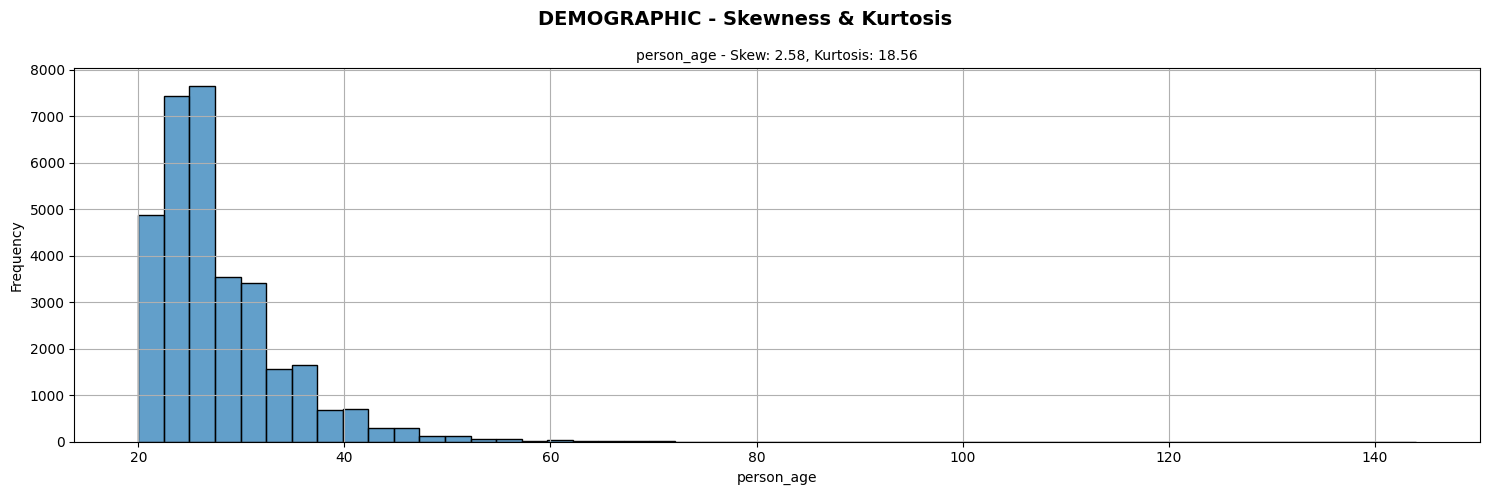


DEMOGRAPHIC - CATEGORICAL FEATURES (3):

gender (2 unique values):
gender
Male      16371
Female    16210
Name: count, dtype: int64


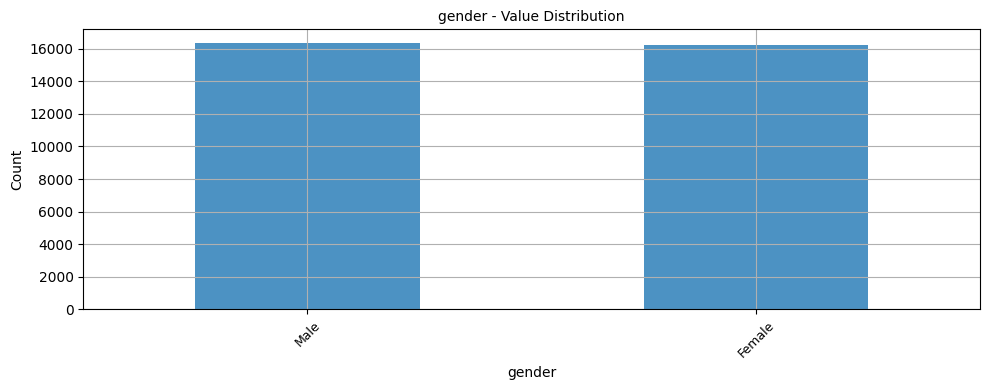


marital_status (4 unique values):
marital_status
Single      16368
Married     11393
Divorced     3173
Widowed      1647
Name: count, dtype: int64


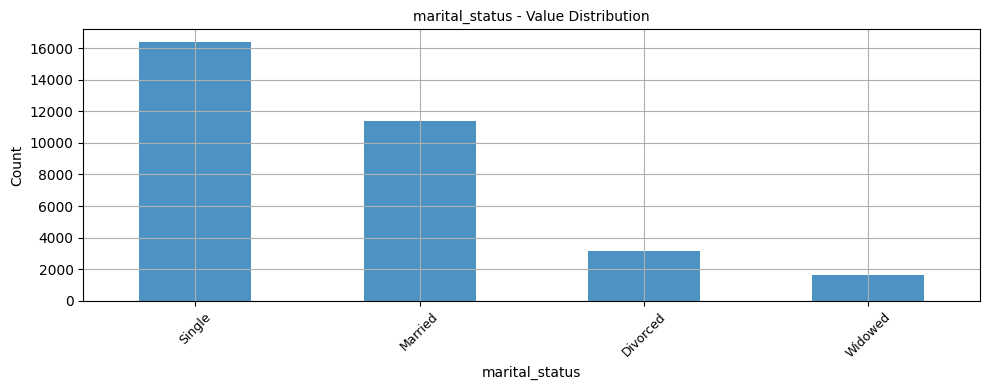


education_level (4 unique values):
education_level
High School    13185
Bachelor       11390
Master          6508
PhD             1498
Name: count, dtype: int64


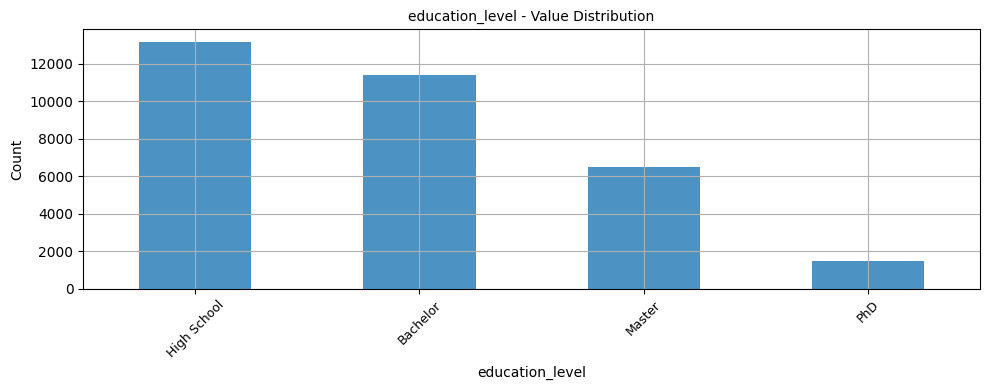


EMPLOYMENT - NUMERIC FEATURES (2):
       person_emp_length  person_income
count           31686.00       32581.00
mean                4.79       66074.85
std                 4.14       61983.12
min                 0.00        4000.00
25%                 2.00       38500.00
50%                 4.00       55000.00
75%                 7.00       79200.00
max               123.00     6000000.00


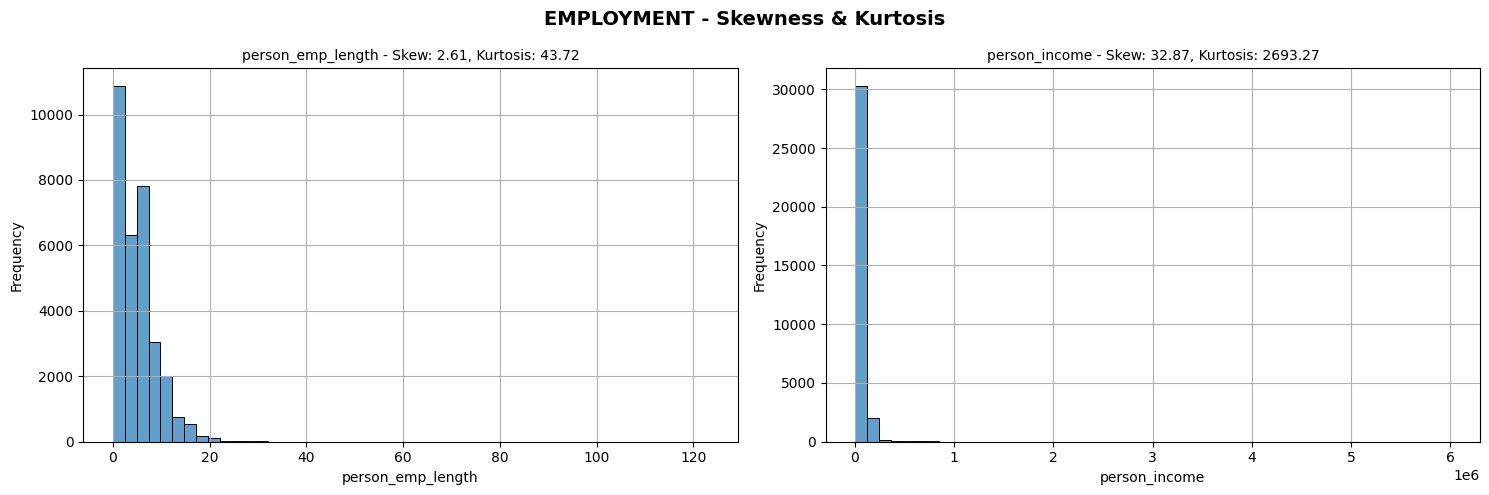


EMPLOYMENT - CATEGORICAL FEATURES (1):

employment_type (4 unique values):
employment_type
Full-time        19473
Part-time         6510
Self-employed     4926
Unemployed        1672
Name: count, dtype: int64


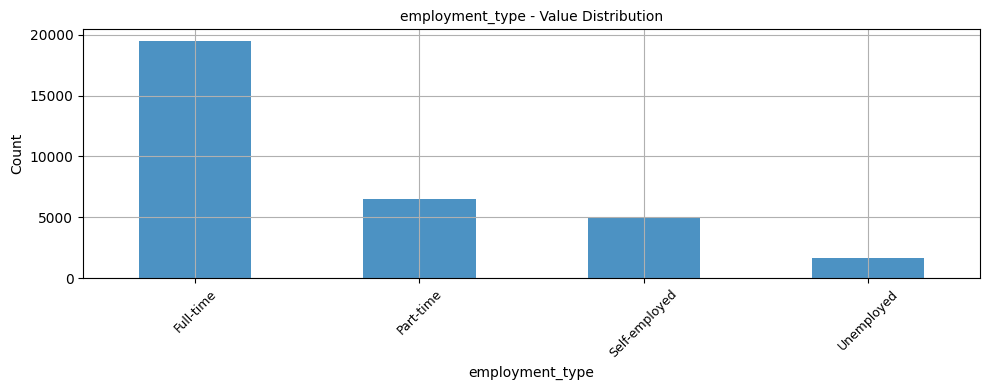


LOAN - NUMERIC FEATURES (4):
       loan_amnt  loan_int_rate  loan_term_months  loan_percent_income
count   32581.00       29465.00          32581.00             32581.00
mean     9589.37          11.01             38.50                 0.17
std      6322.09           3.24             16.01                 0.11
min       500.00           5.42             12.00                 0.00
25%      5000.00           7.90             24.00                 0.09
50%      8000.00          10.99             36.00                 0.15
75%     12200.00          13.47             60.00                 0.23
max     35000.00          23.22             60.00                 0.83


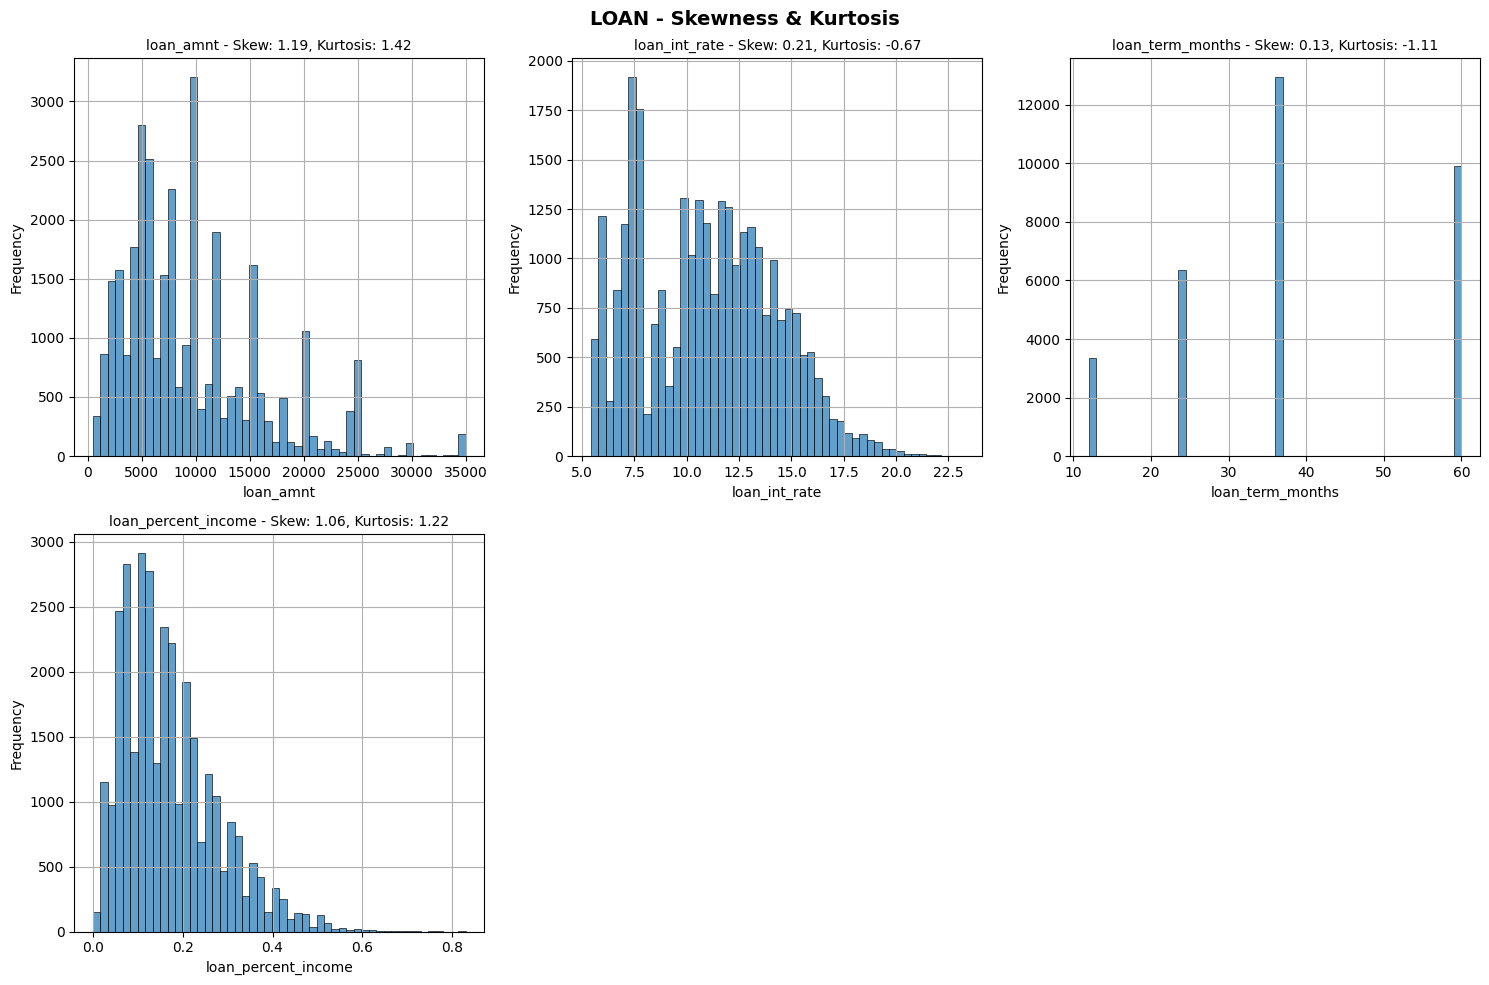


LOAN - CATEGORICAL FEATURES (2):

loan_intent (6 unique values):
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64


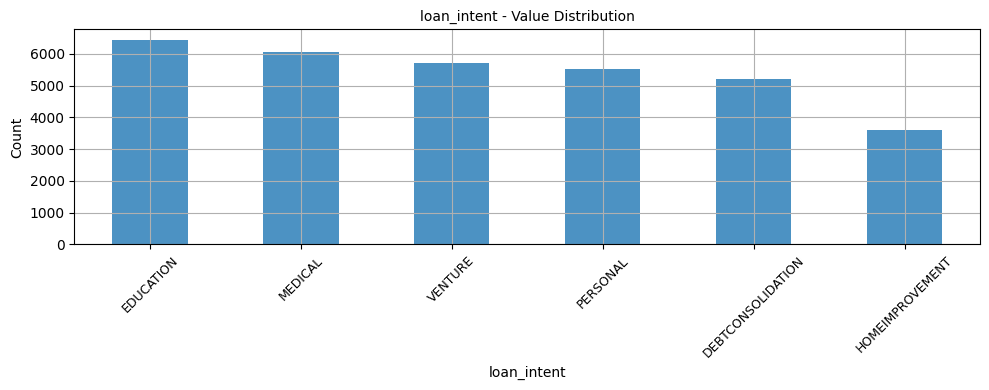


loan_grade (7 unique values):
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64


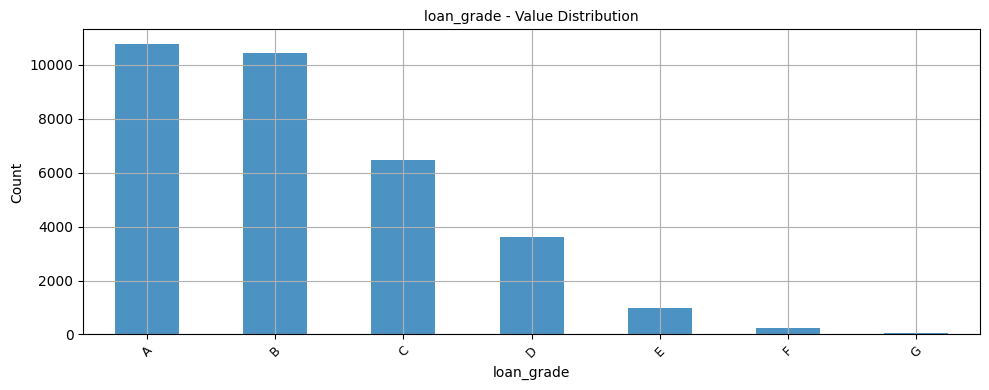


FINANCIAL - NUMERIC FEATURES (4):
       loan_to_income_ratio  debt_to_income_ratio  other_debt  \
count              32581.00              32581.00    32581.00   
mean                   0.17                  0.35    11567.96   
std                    0.11                  0.13    13060.93   
min                    0.00                  0.06      225.21   
25%                    0.09                  0.25     5387.17   
50%                    0.15                  0.33     8995.07   
75%                    0.23                  0.42    14562.93   
max                    0.83                  1.05  1187998.91   

       credit_utilization_ratio  
count                  32581.00  
mean                       0.50  
std                        0.26  
min                        0.05  
25%                        0.28  
50%                        0.50  
75%                        0.73  
max                        0.95  


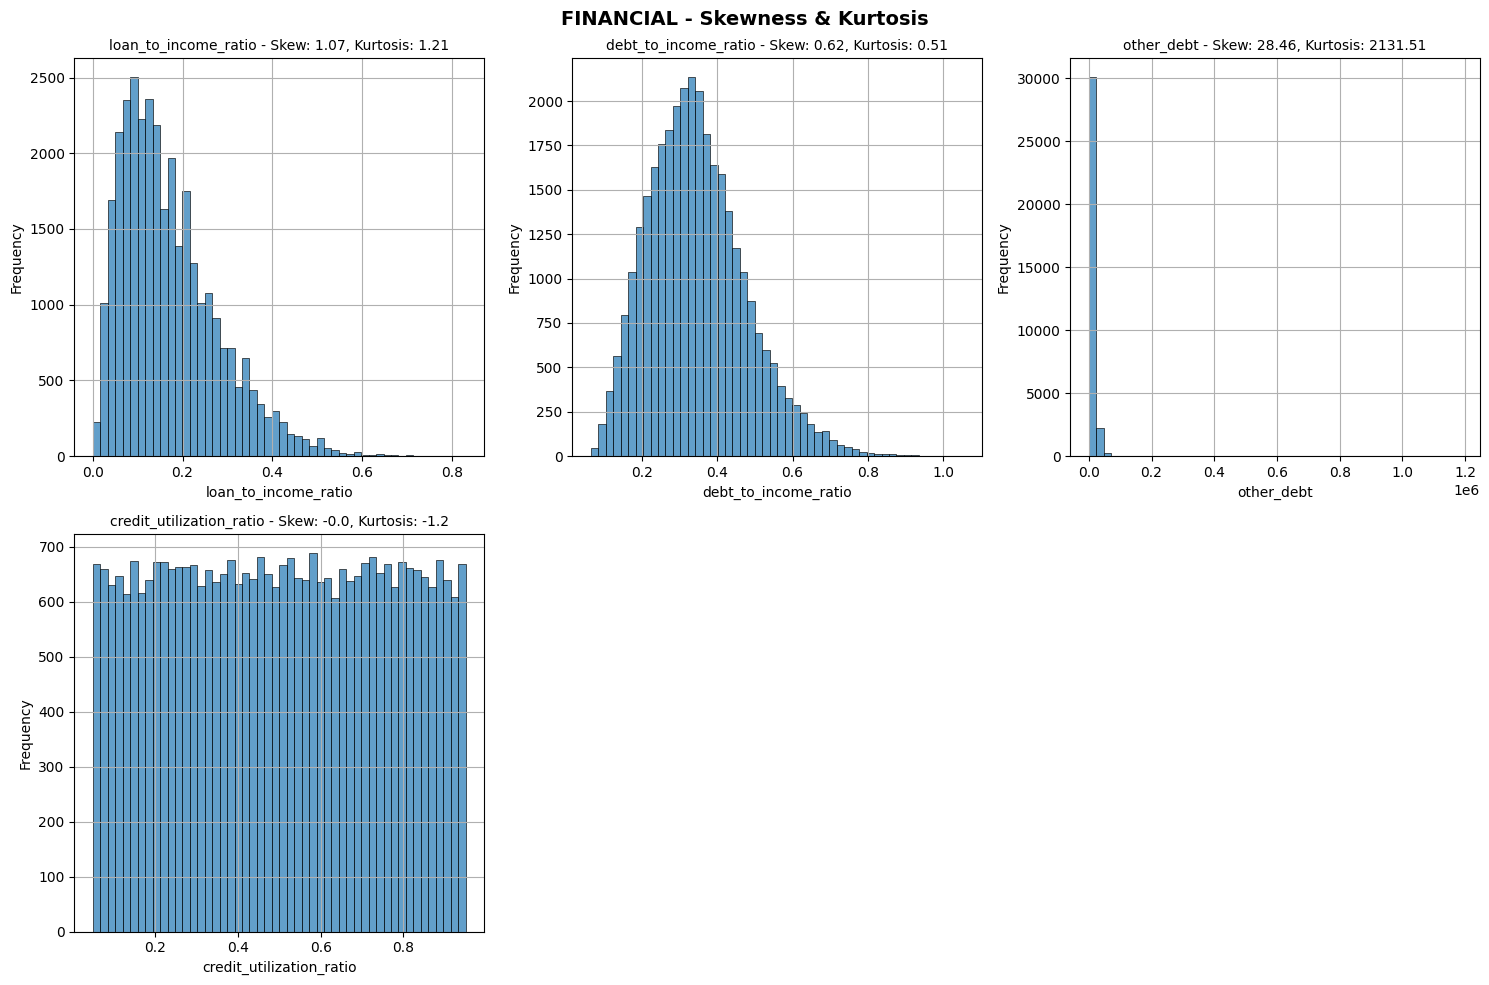

No categorical features to visualize in financial

CREDIT_HISTORY - NUMERIC FEATURES (3):
       cb_person_cred_hist_length  past_delinquencies  open_accounts
count                    32581.00            32581.00       32581.00
mean                         5.80                0.51           8.04
std                          4.06                0.71           4.33
min                          2.00                0.00           0.00
25%                          3.00                0.00           4.00
50%                          4.00                0.00           8.00
75%                          8.00                1.00          12.00
max                         30.00                6.00          15.00


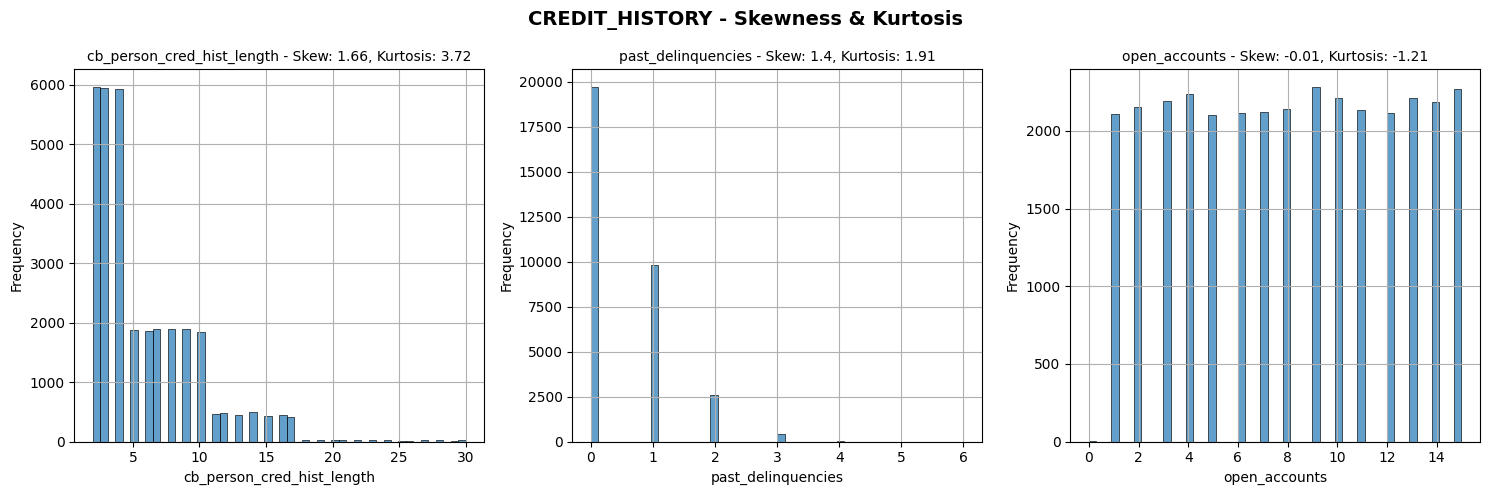


CREDIT_HISTORY - CATEGORICAL FEATURES (1):

cb_person_default_on_file (2 unique values):
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


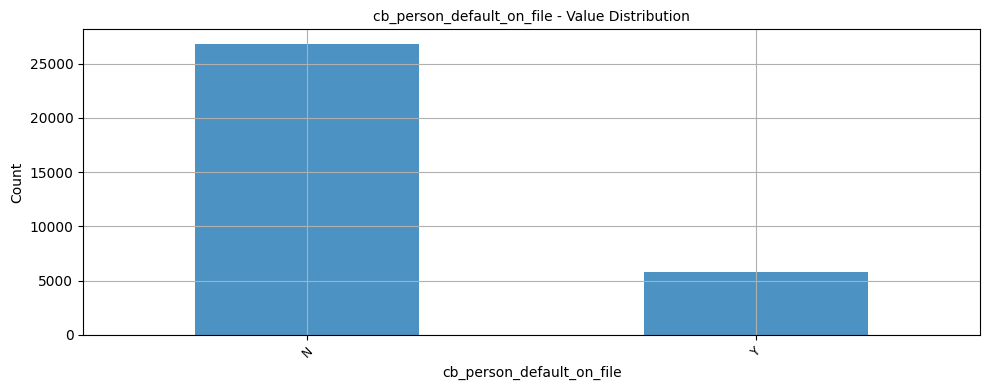

No numeric features to visualize in housing

HOUSING - CATEGORICAL FEATURES (1):

person_home_ownership (4 unique values):
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64


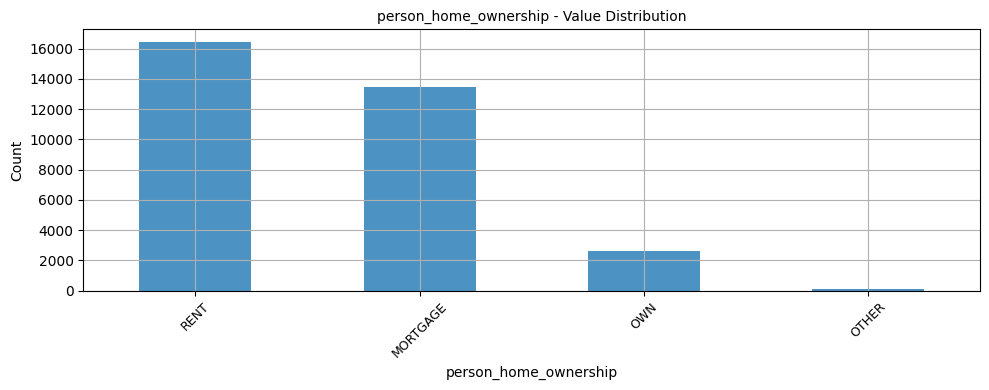


GEOGRAPHIC - NUMERIC FEATURES (2):
       city_latitude  city_longitude
count       32581.00        32581.00
mean           45.41          -63.81
std             7.64           46.62
min            29.76         -123.37
25%            40.71          -96.80
50%            46.81          -75.70
75%            51.51           -3.94
max            55.95           -0.13


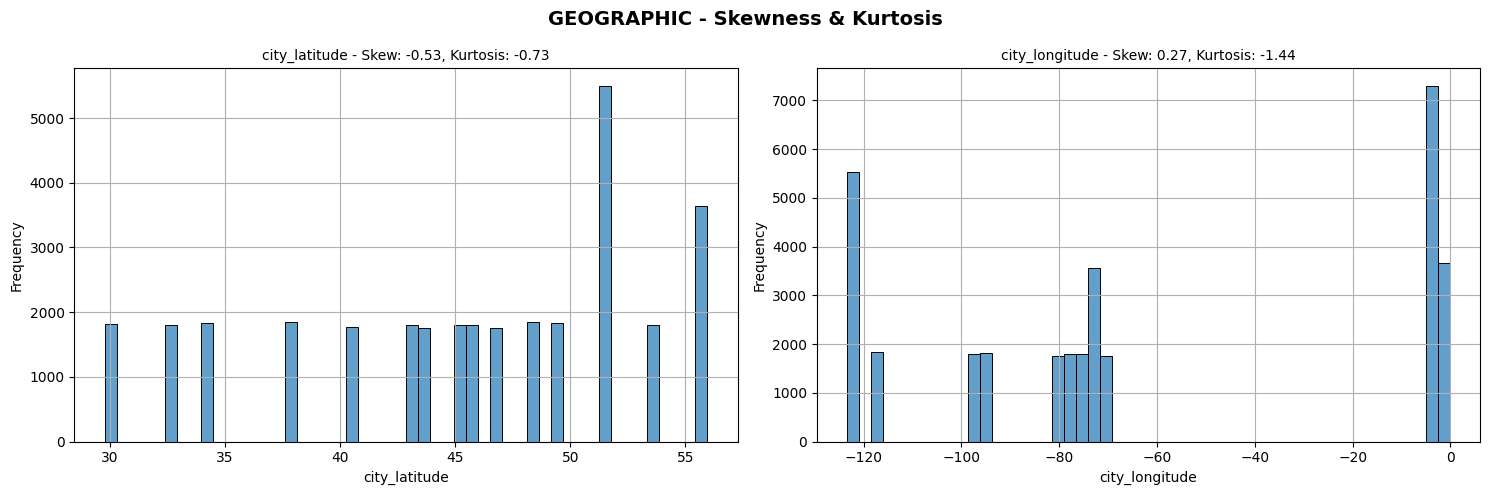


GEOGRAPHIC - CATEGORICAL FEATURES (3):

country (3 unique values):
country
UK        10944
USA       10852
Canada    10785
Name: count, dtype: int64


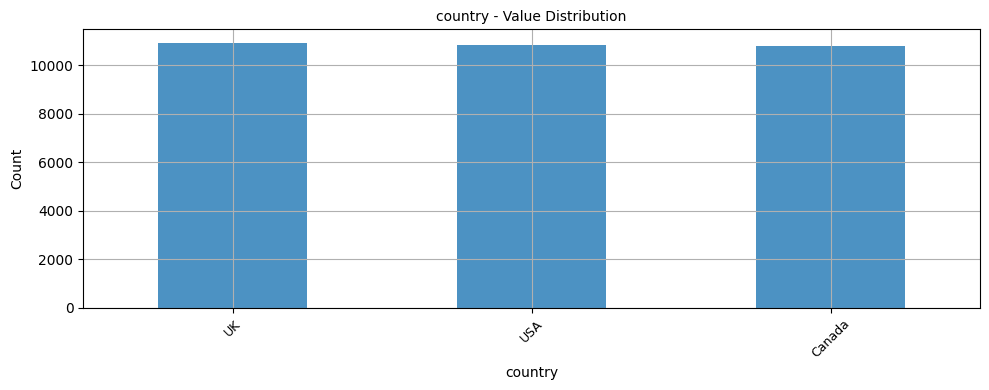


state (9 unique values):
state
BC            3679
California    3679
England       3654
Scotland      3648
Wales         3642
Texas         3608
New York      3565
Ontario       3553
Quebec        3553
Name: count, dtype: int64


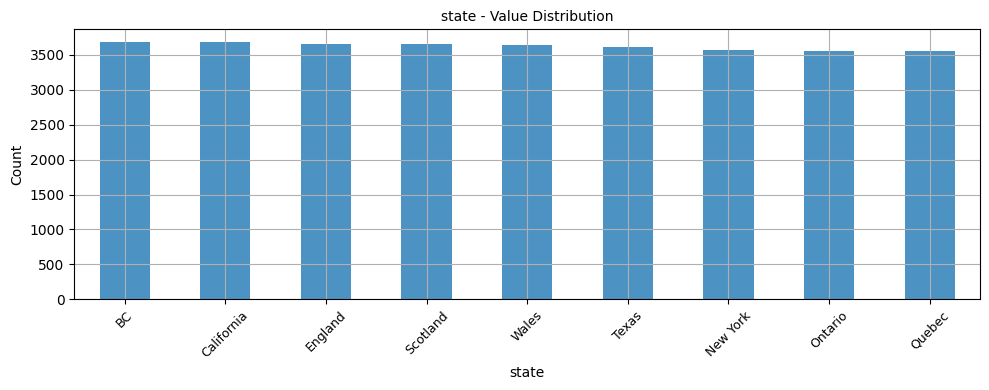


city (18 unique values):
city
Victoria         1852
London           1851
Glasgow          1841
San Francisco    1841
Los Angeles      1838
Cardiff          1831
Vancouver        1827
Swansea          1811
Houston          1811
Edinburgh        1807
Name: count, dtype: int64


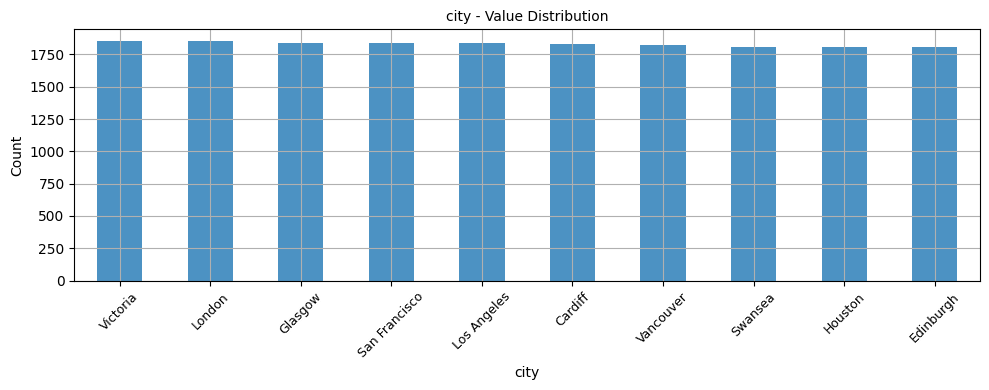

In [8]:
print("=" * 10, "ANALYSIS BY FEATURE GROUP" ,"=" * 10)

def visualization_numeric_features(features, group_name):
  if not features:
    print(f"No numeric features to visualize in {group_name}")
    return

  print(f"\n{group_name.upper()} - NUMERIC FEATURES ({len(features)}):")

  # Statistical summary
  summary_stats = df[features].describe().round(2)
  print(summary_stats)

  # Distribution analysis
  n_features = len(features)
  if n_features >= 1:
    n_cols = min(3, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize = (15, 5 * n_rows))
    if n_rows == 1 and n_cols == 1:
      axes = [axes]
    elif n_rows == 1:
      axes = axes.flatten()
    else:
      axes = axes.flatten()

    for i, feature in enumerate(features):
      if i < len(axes):
        # Distribution plot
        sns.histplot(data=df[feature], ax=axes[i], alpha=0.7, bins=50)

        # Statistics
        skew = df[feature].skew().round(2)
        kurtosis = df[feature].kurtosis().round(2)

        axes[i].set_title(f"{feature} - Skew: {skew}, Kurtosis: {kurtosis}", fontsize = 10)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Frequency")
        axes[i].grid(True)

    for i in range(len(features), len(axes)):
      fig.delaxes(axes[i])

    plt.suptitle(f"{group_name.upper()} - Skewness & Kurtosis", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

def visualization_categorical_features(features, group_name):
  # Analyze categorical features with value counts
  if not features:
    print(f"No categorical features to visualize in {group_name}")
    return

  print(f"\n{group_name.upper()} - CATEGORICAL FEATURES ({len(features)}):")

  for feature in features:
    plot_series = df[feature].fillna("Missing")

    value_counts = df[feature].value_counts()
    n_unique = df[feature].nunique()

    print(f"\n{feature} ({n_unique} unique values):")
    print(value_counts.head(10))

    # Visualize if reasonable number of categories
    if n_unique <= 20:
        plt.figure(figsize=(10, 4))
        value_counts.head(10).plot(kind='bar', alpha=0.8)
        plt.title(f'{feature} - Value Distribution', fontsize = 10)
        plt.xlabel(feature)
        plt.ylabel('Count')
        plt.xticks(rotation=45, fontsize=9)
        plt.tight_layout()
        plt.grid(True)
        plt.show()

# Analyze each feature group
for group_name, features in available_features.items():
    if features:
        # Split by type
        group_numeric = [f for f in features if f in NUMERIC_FEATURES]
        group_categorical = [f for f in features if f in CATEGORICAL_FEATURES]

        visualization_numeric_features(group_numeric, group_name)
        visualization_categorical_features(group_categorical, group_name)

========== BIVARIATE ANALYSIS - FEATURES AND TARGET ==========

BIVARIATE ANALYSIS TARGET - NUMERIC FEATURES (16):

loan_to_income_ratio:
  Good customers: μ=0.15, σ=0.09
  Bad customers:  μ=0.25, σ=0.13
  Mann-Whitney p-value: 0.000e+00
  KS test p-value: 0.000e+00
  *** Highly significant difference

loan_int_rate:
  Good customers: μ=10.44, σ=2.98
  Bad customers:  μ=13.06, σ=3.29
  Mann-Whitney p-value: 0.000e+00
  KS test p-value: 0.000e+00
  *** Highly significant difference

loan_percent_income:
  Good customers: μ=0.15, σ=0.09
  Bad customers:  μ=0.25, σ=0.13
  Mann-Whitney p-value: 0.000e+00
  KS test p-value: 0.000e+00
  *** Highly significant difference

debt_to_income_ratio:
  Good customers: μ=0.32, σ=0.11
  Bad customers:  μ=0.42, σ=0.15
  Mann-Whitney p-value: 0.000e+00
  KS test p-value: 0.000e+00
  *** Highly significant difference

person_income:
  Good customers: μ=70804.36, σ=66568.80
  Bad customers:  μ=49125.65, σ=36907.38
  Mann-Whitney p-value: 0.000e+00
  KS te

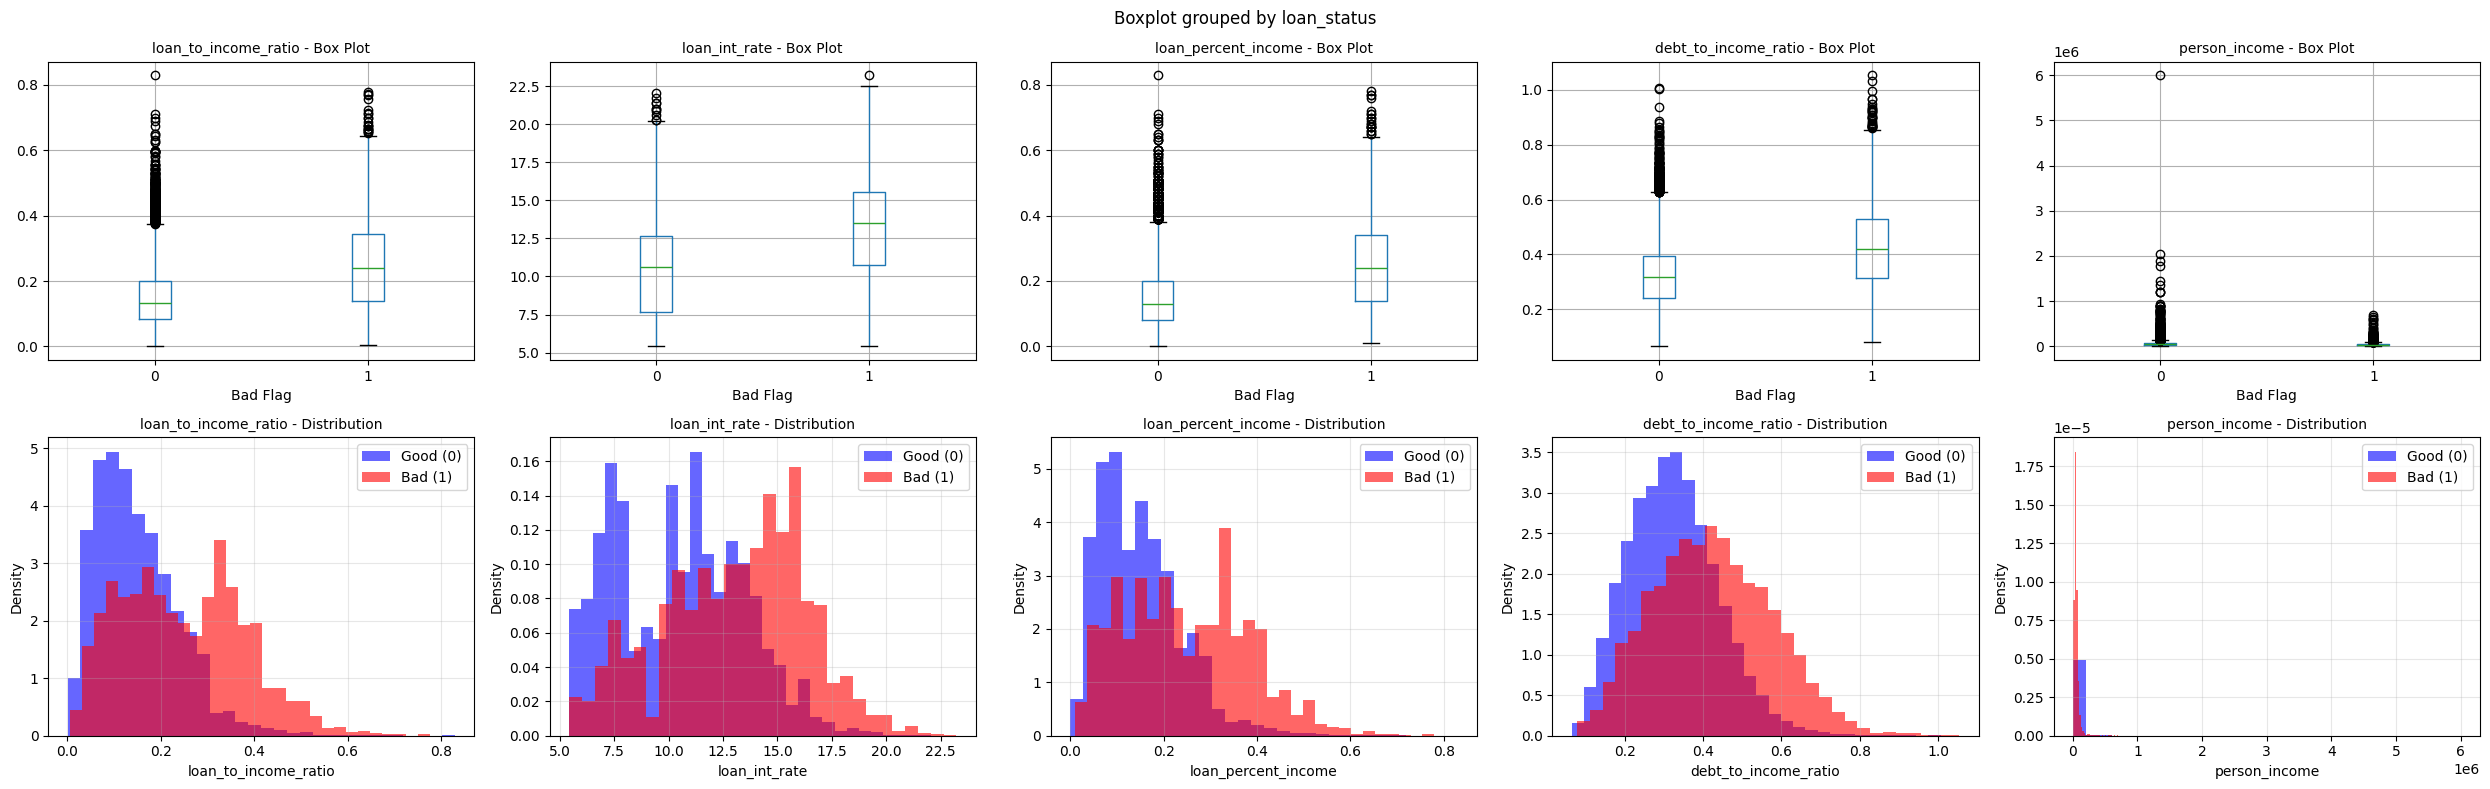


BIVARIATE ANALYSIS TARGET - CATEGORICAL FEATURES (Top 11):

gender:
  Chi-square p-value: 8.288e-01
  Top 5 categories by bad rate:
        Total  Bad_Count  Bad_Rate
gender                            
Female  16210       3545    0.2187
Male    16371       3563    0.2176


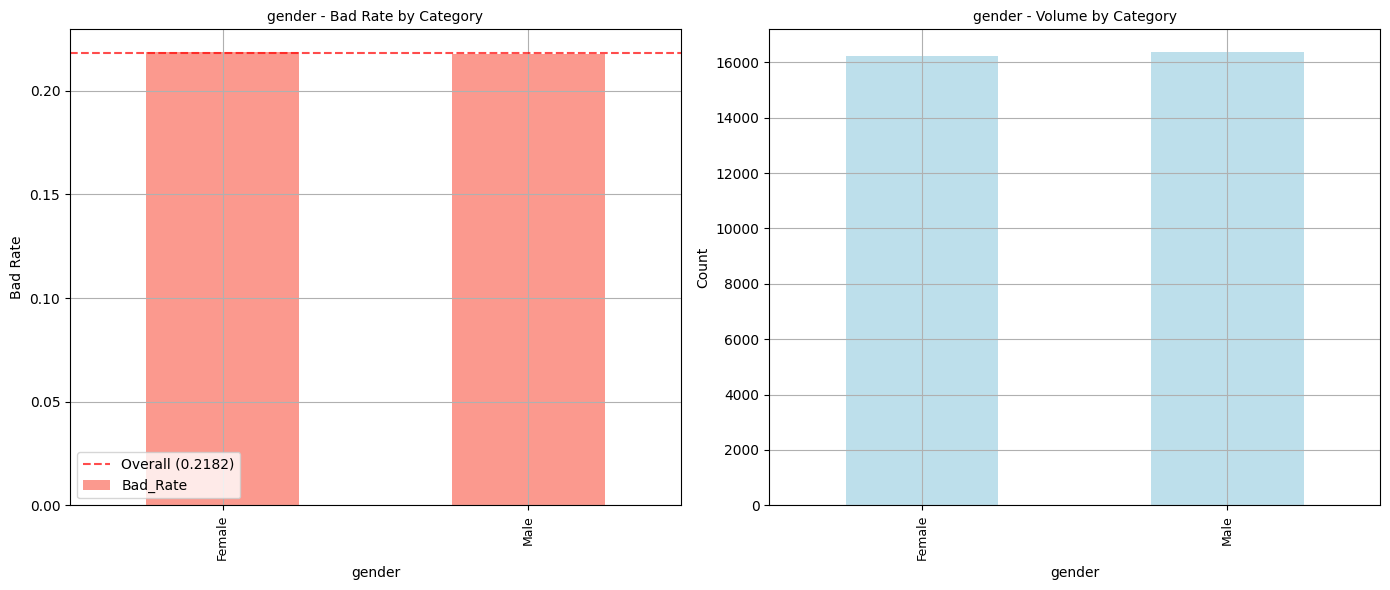


marital_status:
  Chi-square p-value: 9.487e-01
  Top 5 categories by bad rate:
                Total  Bad_Count  Bad_Rate
marital_status                            
Married         11393       2502    0.2196
Divorced         3173        692    0.2181
Single          16368       3562    0.2176
Widowed          1647        352    0.2137


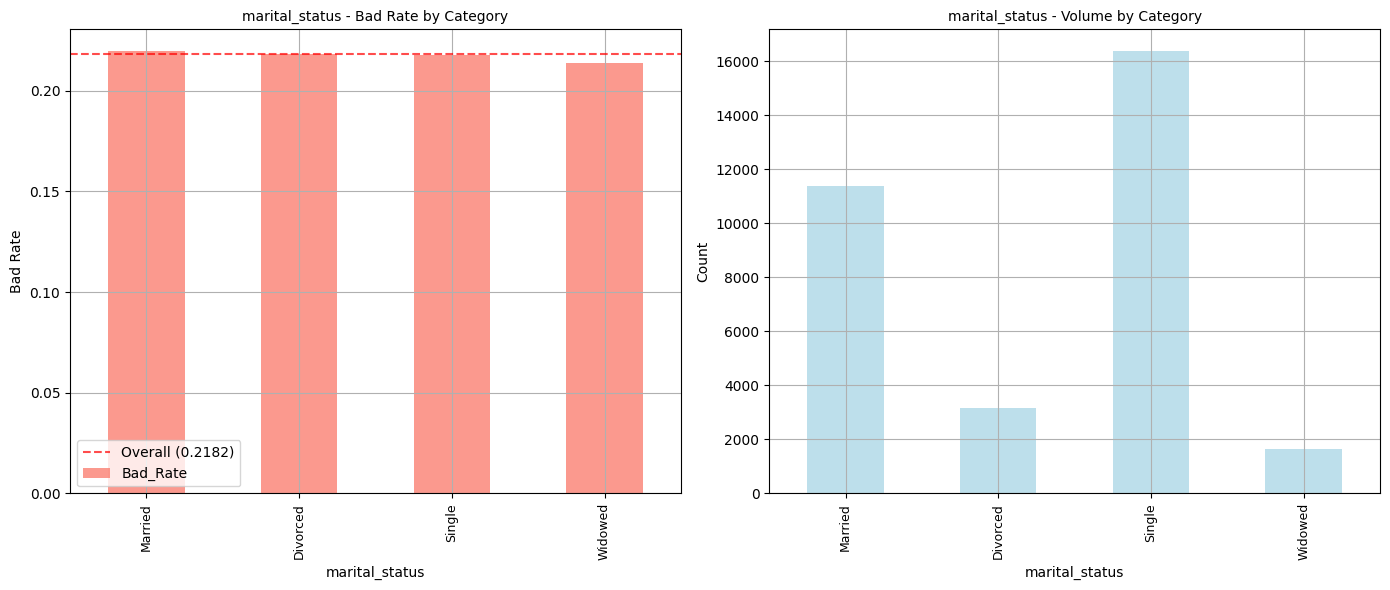


education_level:
  Chi-square p-value: 4.909e-01
  Top 5 categories by bad rate:
                 Total  Bad_Count  Bad_Rate
education_level                            
Master            6508       1443    0.2217
High School      13185       2909    0.2206
Bachelor         11390       2439    0.2141
PhD               1498        317    0.2116


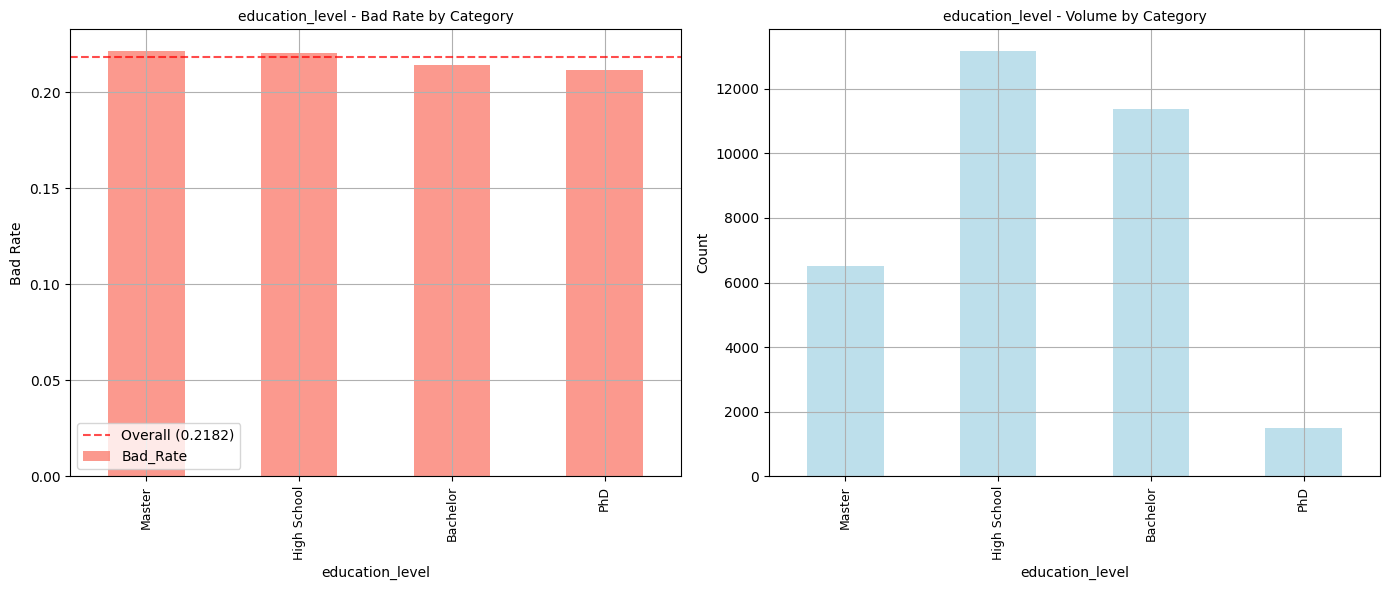


employment_type:
  Chi-square p-value: 4.343e-01
  Top 5 categories by bad rate:
                 Total  Bad_Count  Bad_Rate
employment_type                            
Unemployed        1672        379    0.2267
Self-employed     4926       1108    0.2249
Part-time         6510       1421    0.2183
Full-time        19473       4200    0.2157


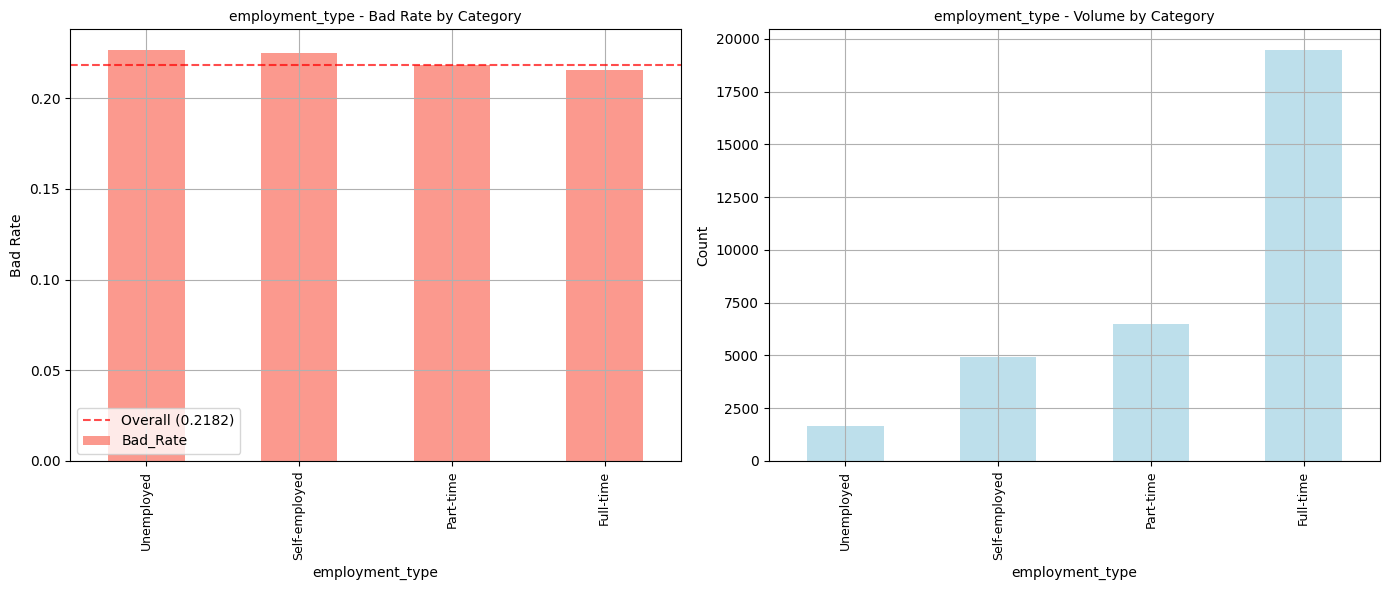


loan_intent:
  Chi-square p-value: 2.981e-110
  Top 5 categories by bad rate:
                   Total  Bad_Count  Bad_Rate
loan_intent                                  
DEBTCONSOLIDATION   5212       1490    0.2859
MEDICAL             6071       1621    0.2670
HOMEIMPROVEMENT     3605        941    0.2610
PERSONAL            5521       1098    0.1989
EDUCATION           6453       1111    0.1722


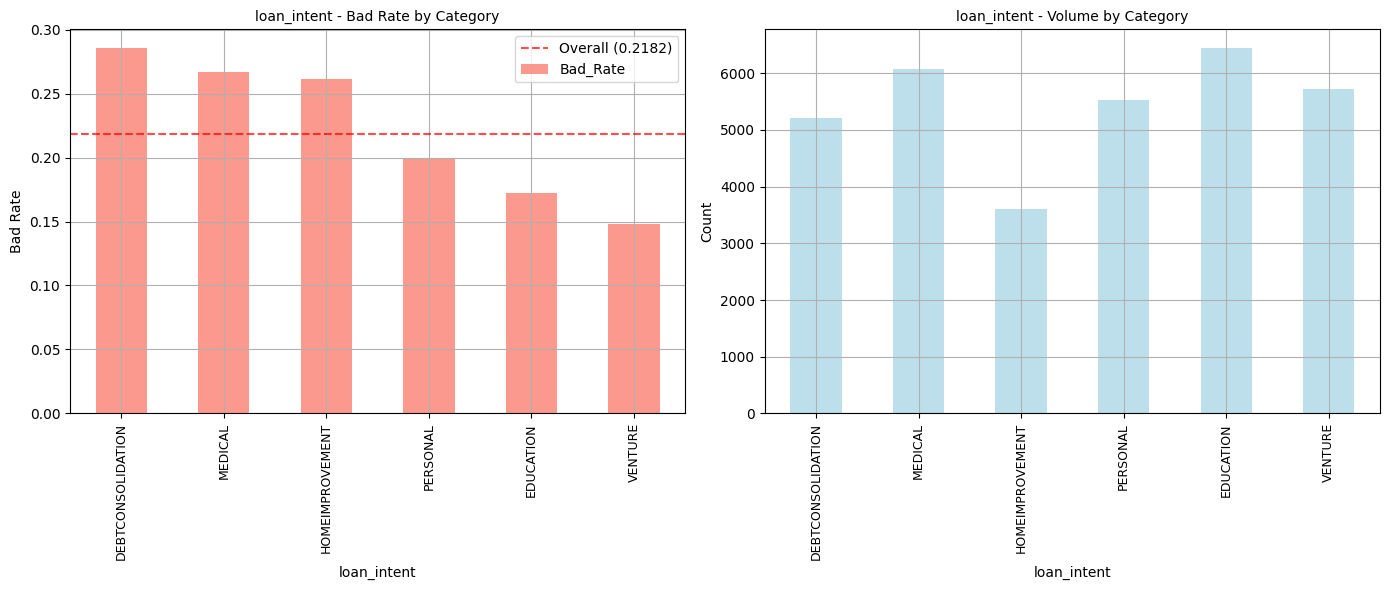

In [9]:
print("=" * 10, "BIVARIATE ANALYSIS - FEATURES AND TARGET", "=" * 10)
def visualization_bivariate_numeric(features, max_features):
  # Analyze numeric features and target with statistical
  if not features:
    return

  print(f"\nBIVARIATE ANALYSIS TARGET - NUMERIC FEATURES ({len(features)}):")

  if "TOP_PREDICTIVE_FEATURES" in globals():
    analysis_features = [f for f in TOP_PREDICTIVE_FEATURES if f in features][:max_features]
  else:
    analysis_features = features[:max_features]

  for feature in analysis_features:
    good_data = df[df[target_features] == 0][feature].dropna()
    bad_data = df[df[target_features] == 1][feature].dropna()

    # Statistical check
    try:
      mw_stat, mw_p = mannwhitneyu(good_data, bad_data, alternative = "two-sided")
      ks_stat, ks_p = ks_2samp(good_data, bad_data)

      print(f"\n{feature}:")
      print(f"  Good customers: μ={good_data.mean():.2f}, σ={good_data.std():.2f}")
      print(f"  Bad customers:  μ={bad_data.mean():.2f}, σ={bad_data.std():.2f}")
      print(f"  Mann-Whitney p-value: {mw_p:.3e}")
      print(f"  KS test p-value: {ks_p:.3e}")

      if mw_p < 0.001:
          print(f"  *** Highly significant difference")
      elif mw_p < 0.05:
          print(f"  ** Significant difference")
      else:
          print(f"  No significant difference")
    except Exception as e:
        print(f"\n{feature}: Unable to perform statistical tests - {e}")

  # Visualization
  if analysis_features:
      n_features_to_plot = len(analysis_features)
      fig, axes = plt.subplots(2, n_features_to_plot, figsize=(5*n_features_to_plot, 8))
      if n_features_to_plot == 1:
          axes = axes.reshape(-1, 1)

      for i, feature in enumerate(analysis_features):
          # Box plot
          df.boxplot(column=feature, by=target_features, ax=axes[0, i])
          axes[0, i].set_title(f'{feature} - Box Plot', fontsize=10)
          axes[0, i].set_xlabel('Bad Flag') # Label still refers to bad flag conceptually

          # Histogram overlay
          good_data_hist = df[df[target_features] == 0][feature].dropna()
          bad_data_hist = df[df[target_features] == 1][feature].dropna()

          axes[1, i].hist(good_data_hist, bins=30, alpha=0.6, label='Good (0)', density=True, color='blue')
          axes[1, i].hist(bad_data_hist, bins=30, alpha=0.6, label='Bad (1)', density=True, color='red')
          axes[1, i].set_title(f'{feature} - Distribution', fontsize=10)
          axes[1, i].set_xlabel(feature)
          axes[1, i].set_ylabel('Density')
          axes[1, i].legend()
          axes[1, i].grid(alpha=0.3)

      plt.tight_layout()
      plt.show()

def visualization_bivariate_categorical(features, max_features):
  # Analyze categorical features and target with bad_rate
  if not features:
    return

  print(f"\nBIVARIATE ANALYSIS TARGET - CATEGORICAL FEATURES (Top {len(features)}):")
  analysis_features = features[:max_features]

  for feature in analysis_features:
      # Chi-square test
      try:
          contingency = pd.crosstab(df[feature], df[target_features])
          chi2, p_value, dof, expected = chi2_contingency(contingency)

          # Bad rate by category
          bad_rate_analysis = df.groupby(feature)[target_features].agg(['count', 'sum', 'mean']).round(4)
          bad_rate_analysis.columns = ['Total', 'Bad_Count', 'Bad_Rate']
          bad_rate_analysis = bad_rate_analysis.sort_values('Bad_Rate', ascending=False)

          print(f"\n{feature}:")
          print(f"  Chi-square p-value: {p_value:.3e}")
          print(f"  Top 5 categories by bad rate:")
          print(bad_rate_analysis.head())

          # Visualization
          plt.figure(figsize=(14, 6))

          plt.subplot(1, 2, 1)
          bad_rate_analysis['Bad_Rate'].head(10).plot(kind='bar', color='salmon', alpha=0.8)
          plt.title(f'{feature} - Bad Rate by Category', fontsize = 10)
          plt.ylabel('Bad Rate', fontsize = 10)
          plt.xticks(rotation=90, fontsize=9)
          plt.axhline(y=df[target_features].mean(), color='red', linestyle='--', alpha=0.7,
                      label=f'Overall ({df[target_features].mean():.4f})')
          plt.grid()
          plt.legend()

          plt.subplot(1, 2, 2)
          bad_rate_analysis['Total'].head(10).plot(kind='bar', color='lightblue', alpha=0.8)
          plt.title(f'{feature} - Volume by Category', fontsize = 10)
          plt.ylabel('Count', fontsize=10)
          plt.xticks(rotation=90, fontsize=9)
          plt.grid()
          plt.tight_layout()
          plt.show()

      except Exception as e:
          print(f"\n{feature}: Unable to perform chi-square test - {e}")

visualization_bivariate_numeric(NUMERIC_FEATURES, 5)
visualization_bivariate_categorical(CATEGORICAL_FEATURES, 5)


# 2. Feature Engineering and Processing

**2.1: Data Leakage detection and processing**

In [10]:
print("=" * 15, "FEATURE LEAKAGE DETECTION (ADVANCED FEATURE ENGINEERING)", "=" * 15)

def advanced_feature_engineering(df, target_col="loan_status"):
    df_fe = df.copy()

    # 1. Remove ID columns
    id_cols = [col for col in df_fe.columns if "id" in col.lower()]

    if id_cols:
        print("1. Removing ID columns:", id_cols)
        df_fe.drop(columns=id_cols, inplace=True, errors="ignore")


    # 2. Handle missing values
    print("2. Handling missing values...")

    numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df_fe.select_dtypes(include=["object"]).columns.tolist()

    if target_col in numeric_cols:
        numeric_cols.remove(target_col)

    for col in numeric_cols:
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())

    for col in categorical_cols:
        df_fe[col] = df_fe[col].fillna("Unknown")


    # 3. Handle outliers using IQR clipping
    print("3. Handling outliers...")

    for col in numeric_cols:
        Q1 = df_fe[col].quantile(0.25)
        Q3 = df_fe[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_fe[col] = df_fe[col].clip(lower, upper)

    # 4. Credit Risk Feature Engineering
    print("4. Creating domain features...")

    if "loan_amnt" in df_fe.columns and "person_income" in df_fe.columns:
        df_fe["loan_income_ratio"] = df_fe["loan_amnt"] / (df_fe["person_income"] + 1)

    if "loan_amnt" in df_fe.columns and "loan_term_months" in df_fe.columns:
        df_fe["monthly_payment"] = df_fe["loan_amnt"] / (df_fe["loan_term_months"] + 1)

    if "person_age" in df_fe.columns:
        df_fe["young_customer"] = (df_fe["person_age"] < 30).astype(int)

    if "debt_to_income_ratio" in df_fe.columns and "credit_utilization_ratio" in df_fe.columns:
      df_fe["credit_risk_ratio"] = (df_fe["credit_utilization_ratio"] * df_fe["debt_to_income_ratio"])

    if "person_income" in df_fe.columns and "loan_amnt" in df_fe.columns:
      df_fe["income_loan_gap"] = (df_fe["person_income"] - df_fe["loan_amnt"])

    # 5. Transform Skew Features
    print("5. Transform Skew features...")
    for column in numeric_cols:
        s = df_fe[column].skew()
        k = df_fe[column].kurtosis()

        if abs(s) > 2 and abs(k) > 3:
            print(f"--> {column}: Applying Yeo-Johnson")
            pt = PowerTransformer(method="yeo-johnson")
            df_fe[column] = pt.fit_transform(df_fe[[column]])

        elif abs(s) > 2:
            print(f"--> {column}: Applying Log Transformation")
            if (df_fe[column] >= 0).all():
                df_fe[column] = np.log1p(df_fe[column])

        elif abs(k) > 3:
            print(f"--> {column}: Applying RobustScaler")
            scaler = RobustScaler()
            df_fe[column] = scaler.fit_transform(df_fe[[column]])

        else:
            print(f"--> {column}: Stable distribution")


    print("\nFeature engineering completed.")
    print("New dataset shape:", df_fe.shape)
    return df_fe

# RUN FEATURE ENGINEERING
df_processed = advanced_feature_engineering(df, target_col="loan_status")

print("\n", "=" * 15, "FEATURE SELECTION - NO DATA LEAKAGE","=" * 15)

# 6. Remove Leakage Features
forbidden_features = ["id", "ID", "client_id", "customer_id", "account_id", "loan_status", "loan_percent_income", "cb_person_cred_hist_length"]
forbidden_features.extend([col for col in df_processed.columns if "id" in col.lower()])
forbidden_features = list(set([col for col in forbidden_features if col in df_processed.columns]))
print("Forbidden features:", forbidden_features)

# 7. Safe Features
safe_features = [col for col in df_processed.columns if col not in forbidden_features]
print(f"Safe features ({len(safe_features)}):", safe_features)

# 8. Missing Quality Check
modeling_features = []
for col in safe_features:
    missing_pct = (df_processed[col].isnull().sum() / len(df_processed))
    if missing_pct < 0.20:
        modeling_features.append(col)
    else:
        print(f"Excluding {col}: {missing_pct:.2%}")

feature_string = ", ".join(f'"{c}"' for c in modeling_features)

feature_wrapped = textwrap.fill(feature_string, width=220)
print("\nFinal modeling features:", len(modeling_features))
print("List features:", feature_wrapped)

=============== FEATURE LEAKAGE DETECTION (ADVANCED FEATURE ENGINEERING) ===============
1. Removing ID columns: ['client_id']
2. Handling missing values...
3. Handling outliers...
4. Creating domain features...
5. Transform Skew features...
--> person_age: Stable distribution
--> person_income: Stable distribution
--> person_emp_length: Stable distribution
--> loan_amnt: Stable distribution
--> loan_int_rate: Stable distribution
--> loan_percent_income: Stable distribution
--> cb_person_cred_hist_length: Stable distribution
--> city_latitude: Stable distribution
--> city_longitude: Stable distribution
--> loan_term_months: Stable distribution
--> loan_to_income_ratio: Stable distribution
--> other_debt: Stable distribution
--> debt_to_income_ratio: Stable distribution
--> open_accounts: Stable distribution
--> credit_utilization_ratio: Stable distribution
--> past_delinquencies: Stable distribution

Feature engineering completed.
New dataset shape: (32581, 33)

 =============== FEATUR

In [11]:
print("=" * 15, "SPLIT DATA AND SUMMARY FEATURES FOR TRAINING MODEL", "=" * 15)

X = df_processed[modeling_features].copy()
y = df_processed[target_features]

# Train test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\n1. Perform train-test split...")
print(f"Using {len(modeling_features)} features for modeling")
print(f"Initial modeling dataset: X={X.shape}, y={y.shape}")
print(f"Overall bad rate: {y.mean():.4f}")

print("\n2. Final data quality verification...")
print(f"Train set: X={x_train.shape}, y={y_train.shape}, bad_rate={y_train.mean():.4f}")
print(f"Test set:  X={x_test.shape}, y={y_test.shape}, bad_rate={y_test.mean():.4f}")

# Missing values
train_missing = x_train.isnull().sum().sum()
test_missing = x_test.isnull().sum().sum()

print("\n3. Missing values analysis...")
print(f"Missing values in train set: {train_missing}")
print(f"Missing values in test set: {test_missing}")

categorical_modeling_features = x_train.select_dtypes(include=['object']).columns.tolist()
numeric_modeling_features = x_train.select_dtypes(include=['int64','float64']).columns.tolist()

if train_missing > 0 or test_missing > 0:
    print("Processing missing values...")

    # categorical
    for col in categorical_modeling_features:
        x_train[col].fillna("Unknown", inplace=True)
        x_test[col].fillna("Unknown", inplace=True)

    # numeric
    for col in numeric_modeling_features:
        median_value = x_train[col].median()
        x_train[col].fillna(median_value, inplace=True)
        x_test[col].fillna(median_value, inplace=True)

print("\n4. Class distribution:")
print("Train:", y_train.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

# Import preprocessor components here, after numeric_modeling_features and categorical_modeling_features are defined
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_modeling_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_modeling_features)
    ],
    remainder='passthrough'
)

=============== SPLIT DATA AND SUMMARY FEATURES FOR TRAINING MODEL ===============

1. Perform train-test split...
Using 30 features for modeling
Initial modeling dataset: X=(32581, 30), y=(32581,)
Overall bad rate: 0.2182

2. Final data quality verification...
Train set: X=(24435, 30), y=(24435,), bad_rate=0.2182
Test set:  X=(8146, 30), y=(8146,), bad_rate=0.2181

3. Missing values analysis...
Missing values in train set: 0
Missing values in test set: 0

4. Class distribution:
Train: loan_status
0    0.781829
1    0.218171
Name: proportion, dtype: float64
Test: loan_status
0    0.781856
1    0.218144
Name: proportion, dtype: float64


=============== FEATURE SELECTION AND WOE ANALYSIS WITH LOGISTIC REGRESSION ===============
1. Feature selection from Logistic Regression and correlation

==== Logistic Regression Feature Importance ====
              Feature  Coefficient  abs_coef
1       loan_int_rate     0.247273  0.247273
13      city_latitude    -0.042744  0.042744
5   person_emp_length    -0.028711  0.028711
7          person_age    -0.019120  0.019120
11      open_accounts    -0.011290  0.011290
10     city_longitude     0.005487  0.005487

2. WOE (Weight of Evidence) and IV (Information Value) analysis
Feature: loan_int_rate
Information Value: 0.6819
                   count   bad  good  good_dist  bad_dist       WOE        IV
loan_int_rate_bin                                                            
(5.419, 7.51]       6016   526  5490   0.238685  0.081374  1.076085  0.169281
(7.51, 10.25]       5988   809  5179   0.225164  0.125155  0.587275  0.058733
(10.25, 11.86]      5779   958  4821   0.209600  0.1482

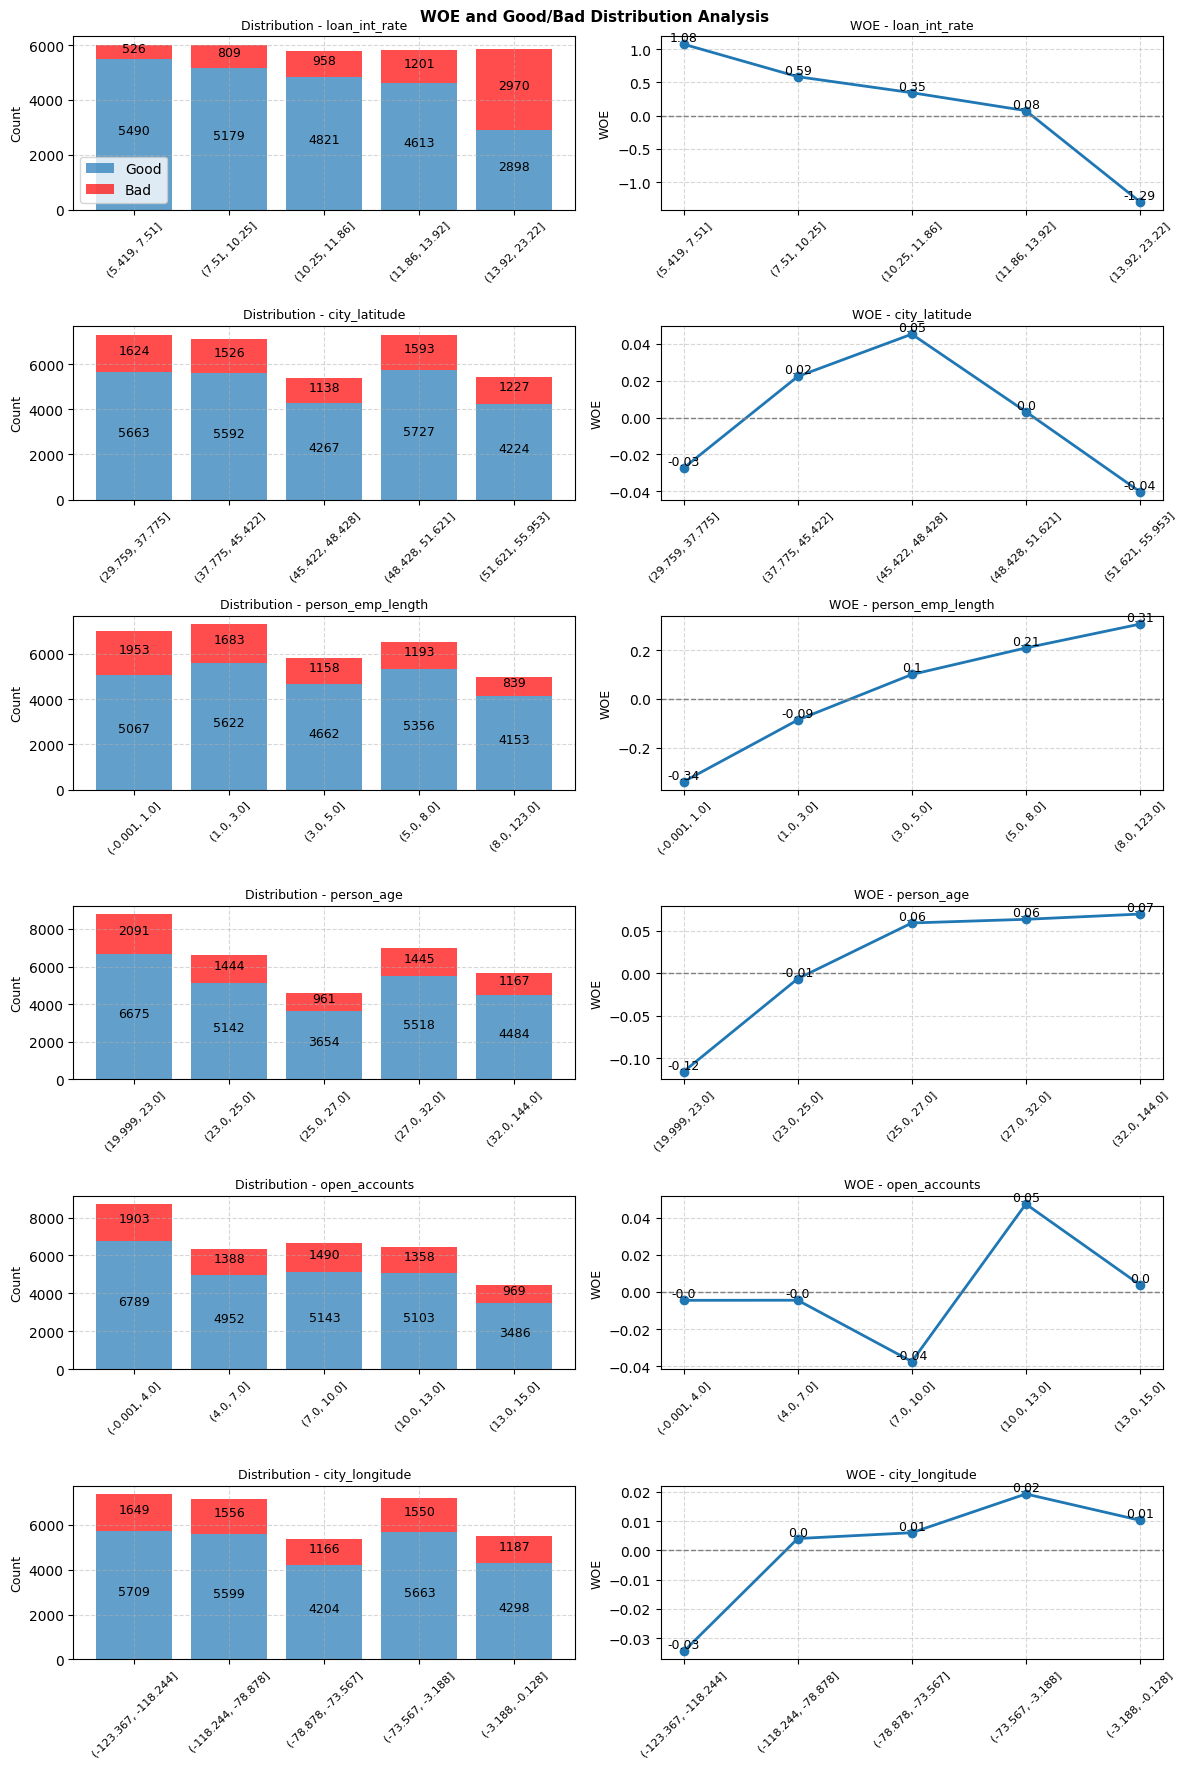

In [12]:
print("=" * 15, "FEATURE SELECTION AND WOE ANALYSIS WITH LOGISTIC REGRESSION" ,"=" * 15)

print("1. Feature selection from Logistic Regression and correlation")
# Filter TOP_PREDICTIVE_FEATURES to only include columns present in x_train
current_top_predictive_features = [f for f in TOP_PREDICTIVE_FEATURES if f in x_train.columns]

# Split features and target using filtered features and y_train
x_woe_selected = x_train[current_top_predictive_features].copy()
y_woe_selected = y_train.copy()

# Identify categorical columns
categorical_cols = x_woe_selected.select_dtypes(include=['object']).columns

# Convert categorical columns to 'category' dtype (for get_dummies)
for col in categorical_cols:
    x_woe_selected[col] = x_woe_selected[col].astype("category")

# One-hot encode categorical features for Logistic Regression
x_lr = pd.get_dummies(x_woe_selected, drop_first=True)

# Train Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_lr.fit(x_lr, y_woe_selected) # Use x_lr for fitting

# Feature importance
importance = pd.DataFrame({
    "Feature": x_lr.columns, # Use columns from x_lr
    "Coefficient": model_lr.coef_[0]
})

importance["abs_coef"] = importance["Coefficient"].abs()
importance = importance.sort_values("abs_coef", ascending=False)

print("\n==== Logistic Regression Feature Importance ====")
print(importance.head(6))
selected_features = importance.head(6)["Feature"].tolist()

print("\n2. WOE (Weight of Evidence) and IV (Information Value) analysis")

def woe_calculations(data, feature, target):
    # Binning (with numeric)
    if data[feature].dtype != 'object':
        data[feature+"_bin"] = pd.qcut(data[feature], q=5, duplicates='drop', retbins=False)
        grouped = data.groupby(feature+"_bin")[target]
    else:
        grouped = data.groupby(feature)[target]

    df_woe = pd.DataFrame()
    df_woe["count"] = grouped.count()
    df_woe["bad"] = grouped.sum()
    df_woe["good"] = df_woe["count"] - df_woe["bad"]

    df_woe["good_dist"] = df_woe["good"] / df_woe["good"].sum()
    df_woe["bad_dist"] = df_woe["bad"] / df_woe["bad"].sum()

    eps = 1e-6
    df_woe["WOE"] = np.log((df_woe["good_dist"]+eps) / (df_woe["bad_dist"]+eps))
    df_woe["IV"] = (df_woe["good_dist"] - df_woe["bad_dist"]) * df_woe["WOE"]
    iv = df_woe["IV"].sum()

    return df_woe, iv

woe_results = {}

# For WOE calculation, we use the original 'df' and target_features
# 'selected_features' now comes from the LR model trained on x_train, so they are guaranteed to be in df_processed, and thus in df.
for feature in [f for f in selected_features if f in df.columns]: # Ensure feature is in original df for WOE calculations
    woe_table, iv = woe_calculations(df, feature, target_features)
    print("==============================")
    print(f"Feature: {feature}")
    print("Information Value:", round(iv,4))
    print(woe_table)
    woe_results[feature] = woe_table

# Plot distribution + WOE together
n_features = len(selected_features)
cols = 2
rows = n_features
fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 3))

# Fix case when only 1 feature
if rows == 1:
    axes = [axes]

for i, feature in enumerate(selected_features):
    if feature not in woe_results: # Skip if WOE was not calculated for this feature
        continue
    woe_table = woe_results[feature]
    x = range(len(woe_table))

    # 1️⃣ Distribution plot
    axes[i][0].bar(x, woe_table["good"], label="Good", alpha=0.7)
    axes[i][0].bar(x, woe_table["bad"], bottom=woe_table["good"], label="Bad", alpha=0.7, color="red")
    axes[i][0].set_title(f"Distribution - {feature}", fontsize=9)
    axes[i][0].set_ylabel("Count", fontsize=9)
    axes[i][0].set_xticks(x)
    axes[i][0].set_xticklabels(woe_table.index.astype(str), rotation=45, fontsize=8)
    axes[i][0].grid(True, linestyle="--", alpha=0.5)

    # Show values on bars
    for j, (g, b) in enumerate(zip(woe_table["good"], woe_table["bad"])):
        axes[i][0].text(j, g/2, int(g), ha="center", color="black", fontsize=9)
        axes[i][0].text(j, g + b/2, int(b), ha="center", color="black", fontsize=9)

    if i == 0:
        axes[i][0].legend()

    # 2️⃣ WOE plot
    axes[i][1].plot(x, woe_table["WOE"], marker="o", linewidth=2)
    axes[i][1].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[i][1].set_title(f"WOE - {feature}", fontsize=9)
    axes[i][1].set_ylabel("WOE", fontsize=9)
    axes[i][1].set_xticks(x)
    axes[i][1].set_xticklabels(woe_table.index.astype(str), rotation=45, fontsize=8)
    axes[i][1].grid(True, linestyle="--", alpha=0.5)

    # Show WOE values
    for j, val in enumerate(woe_table["WOE"]) :
        axes[i][1].text(j, val, round(val,2), ha="center", va="bottom", fontsize=9)

fig.suptitle("WOE and Good/Bad Distribution Analysis", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()

In [13]:
def create_credit_model(model_type, imbalance_strategy="class_weight"):
    model_type = model_type.lower()

    # Ratio calculation
    scale_weight = 2

    if model_type == "logistic":
        model = LogisticRegression(
            random_state=RANDOM_STATE,
            solver="lbfgs",
            max_iter=2000,
            C=1.0,
            class_weight="balanced", penalty="l2"
            if imbalance_strategy == "class_weight"
            else None)
        model_name = "Logistic Regression"

    elif model_type == "random_forest":
        model = RandomForestClassifier(
            n_estimators=600,
            criterion="log_loss",
            max_depth=12,
            min_samples_leaf=5,
            min_samples_split=15,
            max_features="sqrt",
            class_weight="balanced_subsample"
            if imbalance_strategy == "class_weight"
            else None,
            random_state=RANDOM_STATE,
            n_jobs=-1)
        model_name = "Random Forest"

    elif model_type == "mlp":
        model = MLPClassifier(
            hidden_layer_sizes=(128,64,32),
            activation="relu",
            solver="adam",
            alpha=0.01,
            learning_rate_init=0.0005,
            batch_size=128,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=RANDOM_STATE)

        model_name = "MLP Neural Network"

    elif model_type == "xgboost":
        model = XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            min_child_weight=10,
            subsample=0.8,
            colsample_bytree=0.7,
            gamma=0.1,
            reg_alpha=0.2,
            reg_lambda=2,
            scale_pos_weight=scale_weight,
            tree_method="hist",
            eval_metric="auc",
            random_state=RANDOM_STATE,
            n_jobs=-1)

        model_name = "XGBoost"

    elif model_type == "lightgbm":
        model = lgb.LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=4,
            num_leaves=20,
            min_child_samples=80,
            subsample=0.8,
            colsample_bytree=0.7,
            reg_alpha=0.2,
            reg_lambda=2,
            class_weight="balanced"
            if imbalance_strategy == "class_weight"
            else None,
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1)

        model_name = "LightGBM"
    else:
        raise ValueError(
            f"Unknown model type: {model_type}")

    # SMOTE
    if imbalance_strategy == "smote":
        pipeline = ImbPipeline(
          steps=[
                ("preprocessor", preprocessor),
                ("smote",
                 SMOTE(
                     sampling_strategy=0.3,
                     random_state=RANDOM_STATE
                 )),
                ("classifier", model)])
    else:
        pipeline = SkPipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", model)
            ])
    return pipeline, model_name

In [14]:
@dataclass
class RiskMetricsResult:
  model: str
  imbalance_data: str
  accuracy: float
  precision: float
  recall: float
  f1: float
  roc_auc: float
  ks_score: float
  gini: float

def model_computations(model, data_imbalances, y_true, y_prob):
    # Find best threshold
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores = [f1_score(
            y_true,
            (y_prob >= t).astype(int))
        for t in thresholds]

    best_threshold = thresholds[np.argmax(f1_scores)]

    # Final prediction
    y_pred = (y_prob >= best_threshold).astype(int)

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # AUC / GINI
    roc_auc = roc_auc_score(y_true, y_prob)
    gini = 2 * roc_auc - 1

    # KS
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks_score = max(tpr - fpr)


    return RiskMetricsResult(model, data_imbalances, accuracy, precision, recall,
                            f1, roc_auc, ks_score, gini)

def psi_calculations(expected, actual, bins = 10):
  """
  Calculate Population Stability Index (PSI) with handling for duplicate bin edges
  PSI < 0.1: Stable
  0.1 <= PSI < 0.25: Monitor required
  PSI >= 0.25: Investigate required
  """
  # Define breakpoints using quantiles from the expected distribution
  breakpoints_quantiles = np.linspace(0, 1, bins + 1)
  bin_edges = np.unique(np.quantile(expected, breakpoints_quantiles))

  # Add -inf and inf to cover all values
  bin_edges = np.concatenate([[-np.inf], bin_edges, [np.inf]])

  # Calculate the distribution (counts) for expected and actual data within these bins
  expected_counts = np.histogram(expected, bins=bin_edges)[0]
  actual_counts = np.histogram(actual, bins=bin_edges)[0]

  # Convert counts to percentages
  expected_percent = expected_counts / len(expected)
  actual_percent = actual_counts / len(actual)

  # Add a small constant to zero percentages to avoid log(0) and division by zero
  epsilon = 1e-5
  expected_percent = np.where(expected_percent == 0, epsilon, expected_percent)
  actual_percent = np.where(actual_percent == 0, epsilon, actual_percent)

  # Apply the PSI formula
  psi_value = np.sum((expected_percent - actual_percent) * np.log(expected_percent / actual_percent))
  return psi_value

In [15]:
def capture_rate(y_test, y_pred, ratio):
  cutoff = int(len(y_pred) * ratio)
  df = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
  df = df.sort_values('y_pred', ascending=False)
  capture_rate = df.head(cutoff)['y_test'].sum()
  total_churn = df['y_test'].sum()
  return capture_rate / total_churn if total_churn > 0 else np.nan

def find_best_threshold(y_test, y_prob):
  TPR, FPR, thresholds = roc_curve(y_test, y_prob)
  scores = [tpr - fpr for tpr, fpr in zip(TPR, FPR)]
  idx = np.argmax(scores)
  optimal_threshold = thresholds[idx]

  # Handle cases where optimal_threshold might be infinity, leading to zero positive predictions
  if np.isinf(optimal_threshold) or optimal_threshold > 1.0:
      # Find the highest finite threshold available
      finite_thresholds = thresholds[np.isfinite(thresholds)]
      if len(finite_thresholds) > 0:
          # Use the highest finite threshold (thresholds are typically sorted descending)
          return finite_thresholds[0]
      else:
          # Fallback to a default threshold if no finite thresholds are found
          return 0.5
  return optimal_threshold

# Cross-validation function
def cross_validate_model(pipeline, X, y, folds):
  skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
  auc, kss = [], []
  for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    # AUC
    auc.append(roc_auc_score(y_test, y_prob))
    # KS
    FPR, TPR, _ = roc_curve(y_test, y_prob)
    ks = np.max(TPR - FPR)
    kss.append(ks)
  return np.mean(auc), np.mean(kss)

In [16]:
# Train a model with all the combinations
print("=" * 15, "MODEL PERFORMANCE - USING PSI", "=" * 15)
model_configs = [
    ("logistic", "normal"),
    ("logistic", "smote"),
    ("logistic", "class_weight"),
    ("random_forest", "normal"),
    ("random_forest", "smote"),
    ("random_forest", "class_weight"),
    ("mlp", "normal"),
    ("mlp", "smote"),
    ("lightgbm", "normal"),
    ("lightgbm", "smote"),
    ("lightgbm", "class_weight"),
    ("xgboost", "normal"),
    ("xgboost", "smote"),
    ("xgboost", "class_weight")
]
n_splits = 5
results = []

# Initialize all_probs dictionary for storing test probabilities
all_probs = {}

for model_type, strategy in model_configs:
  print(f"\nTraining {model_type} with {strategy}...")
  pipeline, model_name = create_credit_model(model_type, strategy)

  # Cross-validation (pipeline is refit internally)
  cv_auc, kss = cross_validate_model(pipeline, x_train, y_train, folds=n_splits)

  # Fit once on full training set for test evaluation
  pipeline.fit(x_train, y_train)

  # Predict
  y_train_prob = pipeline.predict_proba(x_train)[:, 1]
  y_test_prob = pipeline.predict_proba(x_test)[:, 1]

  # Store probabilities for calibration plots
  current_model_config_name = f"{model_name}_{strategy}"
  all_probs[current_model_config_name] = y_test_prob

  best_threshold = find_best_threshold(y_train, y_train_prob)
  y_test_pred = (y_test_prob >= best_threshold).astype(int)

  FN = ((y_test_pred == 0) & (y_test == 1)).sum()
  TP = ((y_test_pred == 1) & (y_test == 1)).sum()
  FNR = FN / (FN + TP) if FN + TP > 0 else np.nan

  # PR-AUC
  prec, rec, _ = precision_recall_curve(y_test, y_test_prob)
  pr_auc = auc_calculations(rec, prec)
  psi_value = psi_calculations(y_train_prob, y_test_prob, bins=10)
  result = model_computations(model_name, strategy, y_test, y_test_prob)

  # Brier score loss for training data
  brier = brier_score_loss(y_test, y_test_prob)

  # Capture rates
  capture_5 = capture_rate(y_test, y_test_prob, 0.05)
  capture_10 = capture_rate(y_test, y_test_prob, 0.1)
  capture_20 = capture_rate(y_test, y_test_prob, 0.2)

  res_dict = result.__dict__
  res_dict.update({
      "CV_AUC": cv_auc,
      "KSS": kss,
      "FNR": FNR,
      "PR_AUC": pr_auc,
      "BEST_THRESHOLD": best_threshold,
      "CAPTURE_5": capture_5,
      "CAPTURE_10": capture_10,
      "CAPTURE_20": capture_20,
      "PSI": psi_value,
      "BRIER": brier
  })
  results.append(res_dict)

  print(
      f"➤CV-AUC={cv_auc:.4f}, KSS={kss:.4f}, "
      f"TEST-AUC={result.roc_auc:.4f}, KS={result.ks_score:.4f}, "
      f"PSI={psi_value:.4f}, BRIER={brier:.4f}"
  )
  print(f"➤Capture_5%={capture_5:.2%}, " f"Capture_10%={capture_10:.2%}, " f"Capture_20%={capture_20:.2%} ")

=============== MODEL PERFORMANCE - USING PSI ===============

Training logistic with normal...
➤CV-AUC=0.8729, KSS=0.6091, TEST-AUC=0.8759, KS=0.6190, PSI=0.0012, BRIER=0.1370
➤Capture_5%=20.71%, Capture_10%=38.15%, Capture_20%=64.43% 

Training logistic with smote...
➤CV-AUC=0.8727, KSS=0.6087, TEST-AUC=0.8761, KS=0.6181, PSI=0.0014, BRIER=0.1366
➤Capture_5%=20.77%, Capture_10%=38.04%, Capture_20%=64.21% 

Training logistic with class_weight...
➤CV-AUC=0.8728, KSS=0.6089, TEST-AUC=0.8760, KS=0.6195, PSI=0.0014, BRIER=0.1371
➤Capture_5%=20.54%, Capture_10%=38.10%, Capture_20%=64.55% 

Training random_forest with normal...
➤CV-AUC=0.9161, KSS=0.7000, TEST-AUC=0.9212, KS=0.7043, PSI=0.0072, BRIER=0.0691
➤Capture_5%=22.90%, Capture_10%=45.81%, Capture_20%=74.85% 

Training random_forest with smote...
➤CV-AUC=0.9167, KSS=0.7017, TEST-AUC=0.9217, KS=0.7069, PSI=0.0073, BRIER=0.0687
➤Capture_5%=22.90%, Capture_10%=45.81%, Capture_20%=74.79% 

Training random_forest with class_weight...
➤CV-

In [17]:
print("=" * 15, "EVALUATION METRICS", "=" * 15)

results_df = pd.DataFrame(results)

if len(results_df) > 0:

    # Stability-aware ranking
    results_df["auc_gap"] = abs(results_df["roc_auc"] - results_df["CV_AUC"])

    results_df["ranking_score"] = (
        0.4 * results_df["CV_AUC"]
        + 0.4 * results_df["roc_auc"]
        + 0.2 * results_df["ks_score"]
        - 0.5 * results_df["auc_gap"]
    )

    sort_cols = ["ranking_score", "roc_auc", "ks_score", "CAPTURE_10"]
    results_df = results_df.sort_values(sort_cols, ascending=False)

    display_cols = [
        "model", "imbalance_data",
        "CV_AUC", "roc_auc", "auc_gap",
        "ks_score", "PSI",
        "CAPTURE_5", "CAPTURE_10", "CAPTURE_20",
        "ranking_score"
    ]

    top_results = results_df[display_cols].head(15).round(4)

    styled_results = top_results.style.background_gradient(
        cmap="GnBu",
        subset=["CV_AUC", "roc_auc", "ks_score", "CAPTURE_5", "CAPTURE_10", "CAPTURE_20", "ranking_score"]
    ).background_gradient(
        cmap="GnBu_r",
        subset=["PSI", "auc_gap"]
    )

    display(styled_results)

    best = results_df.iloc[0]

    print(f"\nTotal models trained: {len(results_df)}")
    print(f"Best stable model: {best['model']} with {best['imbalance_data']}")
    print(f"Ranking Score={best['ranking_score']:.4f}")
    print(f"CV-AUC={best['CV_AUC']:.4f}, Test-AUC={best['roc_auc']:.4f}, AUC Gap={best['auc_gap']:.4f}")
    print(f"KS={best['ks_score']:.4f}, PSI={best['PSI']:.4f}")
    print(f"Capture@5%={best['CAPTURE_5']:.2%}")
    print(f"Capture@10%={best['CAPTURE_10']:.2%}")
    print(f"Capture@20%={best['CAPTURE_20']:.2%}")

else:
    print("\nNo models were successfully trained.")

=============== EVALUATION METRICS ===============


,model,imbalance_data,CV_AUC,roc_auc,auc_gap,ks_score,PSI,CAPTURE_5,CAPTURE_10,CAPTURE_20,ranking_score
10,LightGBM,class_weight,0.933200,0.939500,0.006300,0.722700,0.000900,0.229000,0.458100,0.759700,0.890500
8,LightGBM,normal,0.933100,0.938400,0.005200,0.722000,0.000600,0.229000,0.458100,0.759700,0.890400
9,LightGBM,smote,0.932300,0.938800,0.006500,0.724400,0.000900,0.229000,0.458100,0.760800,0.890100
11,XGBoost,normal,0.927700,0.932500,0.004800,0.714300,0.001200,0.229000,0.457500,0.754600,0.884600
13,XGBoost,class_weight,0.927700,0.932500,0.004800,0.714300,0.001200,0.229000,0.457500,0.754600,0.884600
12,XGBoost,smote,0.927200,0.932500,0.005400,0.712700,0.000500,0.229000,0.458100,0.755200,0.883700
5,Random Forest,class_weight,0.918300,0.923200,0.004900,0.705600,0.006700,0.229000,0.456900,0.745600,0.875300
4,Random Forest,smote,0.916700,0.921700,0.005000,0.706900,0.007300,0.229000,0.458100,0.747900,0.874300
3,Random Forest,normal,0.916100,0.921200,0.005100,0.704300,0.007200,0.229000,0.458100,0.748500,0.873200
6,MLP Neural Network,normal,0.903900,0.909100,0.005200,0.675600,0.002000,0.228500,0.452400,0.723700,0.857700



Total models trained: 14
Best stable model: LightGBM with class_weight
Ranking Score=0.8905
CV-AUC=0.9332, Test-AUC=0.9395, AUC Gap=0.0063
KS=0.7227, PSI=0.0009
Capture@5%=22.90%
Capture@10%=45.81%
Capture@20%=75.97%


========== ROC, PRECISION-RECALL & CONFUSION MATRIX FOR TOP MODELS ==========
Performance comparison for top 3 models:
                          auc  accuracy  precision  recall  f1_score
model                                                               
LightGBM_class_weight  0.9395    0.9287     0.9430  0.7164    0.8142
LightGBM_normal        0.9384    0.9301     0.9352  0.7304    0.8202
LightGBM_smote         0.9388    0.9333     0.9724  0.7147    0.8239


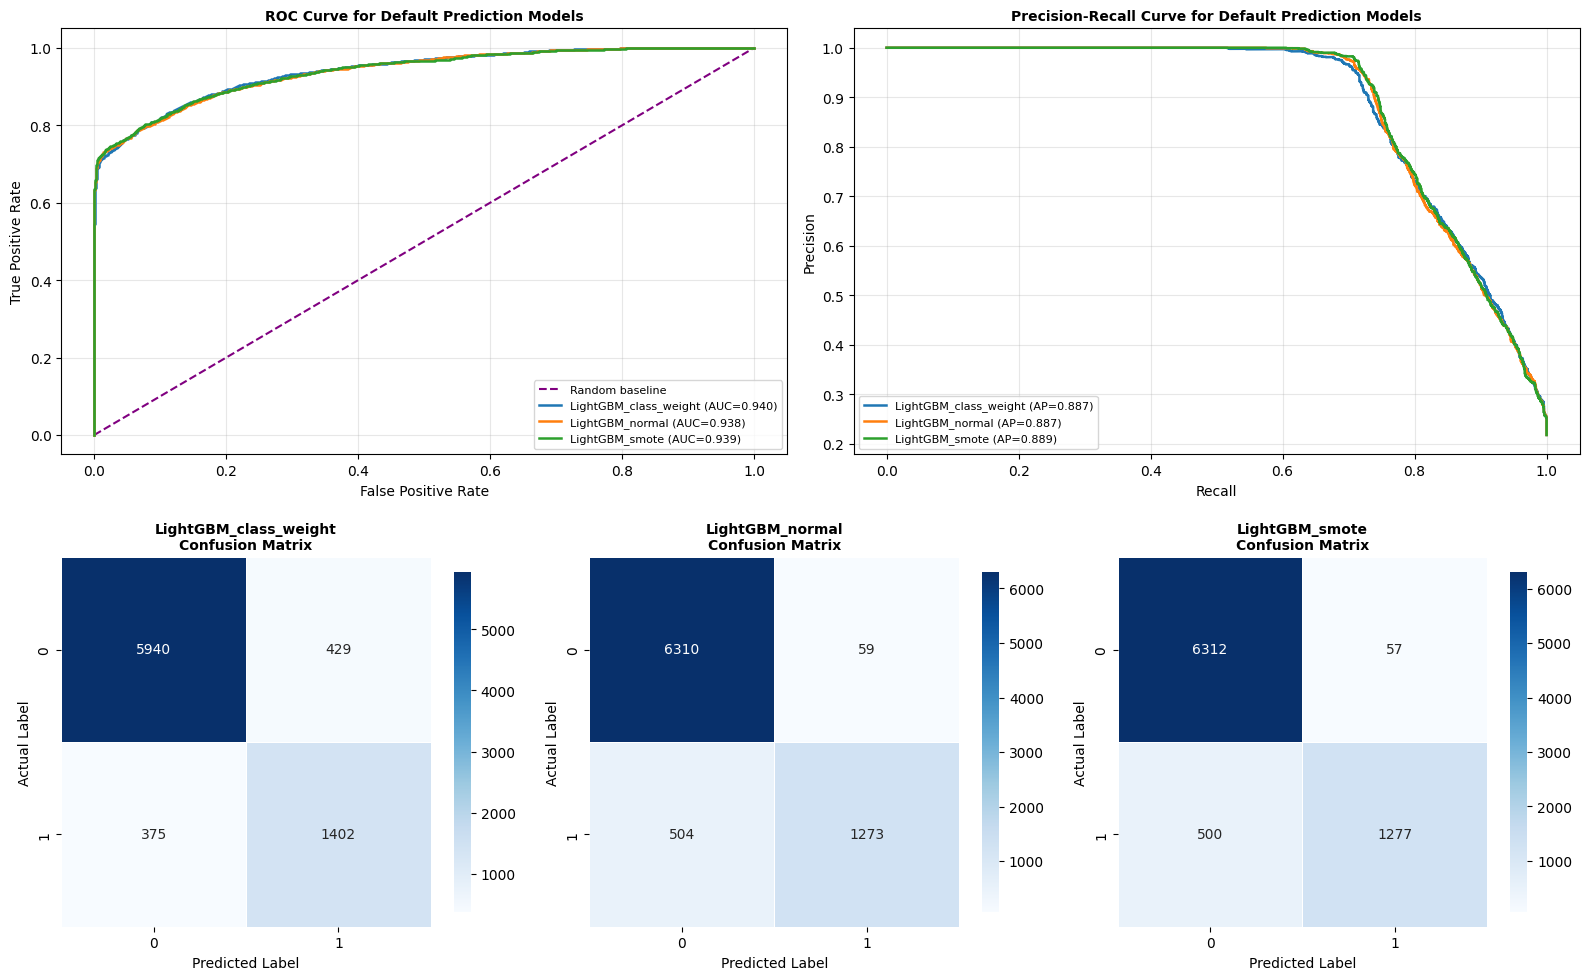

In [18]:
print("=" * 10, "ROC, PRECISION-RECALL & CONFUSION MATRIX FOR TOP MODELS", "=" * 10)

top_models_data = results_df.sort_values("ranking_score", ascending=False).head(3)
model_comparsion_data_for_print = []

for _, row in top_models_data.iterrows():
    model_name = row["model"]
    imbalance_type = row["imbalance_data"]
    found_result = next(
        (
            res for res in results
            if res["model"] == model_name
            and res["imbalance_data"] == imbalance_type
        ),
        None)

    if found_result:
        model_comparsion_data_for_print.append({
            "model": f"{model_name}_{imbalance_type}",
            "auc": found_result["roc_auc"],
            "accuracy": found_result["accuracy"],
            "precision": found_result["precision"],
            "recall": found_result["recall"],
            "f1_score": found_result["f1"]
        })

model_comparsion_df_for_print = (
    pd.DataFrame(model_comparsion_data_for_print)
    .set_index("model"))

print("Performance comparison for top 3 models:")

print(model_comparsion_df_for_print[["auc", "accuracy", "precision", "recall", "f1_score"]].round(4))

# Create dashboard layout
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 6, height_ratios=[1,1])
roc_ax = fig.add_subplot(gs[0, :3])
pr_ax = fig.add_subplot(gs[0, 3:])
cm_axes = [fig.add_subplot(gs[1,0:2]), fig.add_subplot(gs[1,2:4]),fig.add_subplot(gs[1,4:6])]

# ROC Curve & Precision-Recall Curve
roc_ax.plot([0,1], [0,1], color="purple", linestyle="--", linewidth=1.5,label="Random baseline")

for _, row in top_models_data.iterrows():
    name = f"{row.model}_{row.imbalance_data}"
    y_prob = all_probs[name]

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    roc_ax.plot(fpr, tpr, linewidth=1.8, label=f"{name} (AUC={auc_score:.3f})")

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)
    pr_ax.plot(recall, precision, linewidth=1.8, label=f"{name} (AP={ap_score:.3f})")

# ROC Curve Formatting
roc_ax.set_title("ROC Curve for Default Prediction Models", fontsize=10, weight="bold")
roc_ax.set_xlabel("False Positive Rate")
roc_ax.set_ylabel("True Positive Rate")
roc_ax.grid(True, alpha=0.3)
roc_ax.legend(fontsize=8)

# Precision-Recall Curve Formatting
pr_ax.set_title("Precision-Recall Curve for Default Prediction Models", fontsize=10, weight="bold")
pr_ax.set_xlabel("Recall")
pr_ax.set_ylabel("Precision")
pr_ax.grid(True, alpha=0.3)
pr_ax.legend(fontsize=8)

# Confusion Matrix Visualization
for index, (_, row) in enumerate(top_models_data.iterrows()):
    name = f"{row.model}_{row.imbalance_data}"
    y_prob = all_probs[name]

    # Convert probability into prediction using threshold 0.5
    y_pred = (y_prob >= 0.5).astype(int)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=cm_axes[index], cmap="Blues", cbar=True,
                square=True, linewidths=0.5, cbar_kws={"shrink":0.8})
    cm_axes[index].set_title(f"{name}\nConfusion Matrix", fontsize=10, weight="bold")
    cm_axes[index].set_xlabel("Predicted Label")
    cm_axes[index].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

=============== CALIBRATION CURVES & PROBABILITY DISTRIBUTIONS ===============


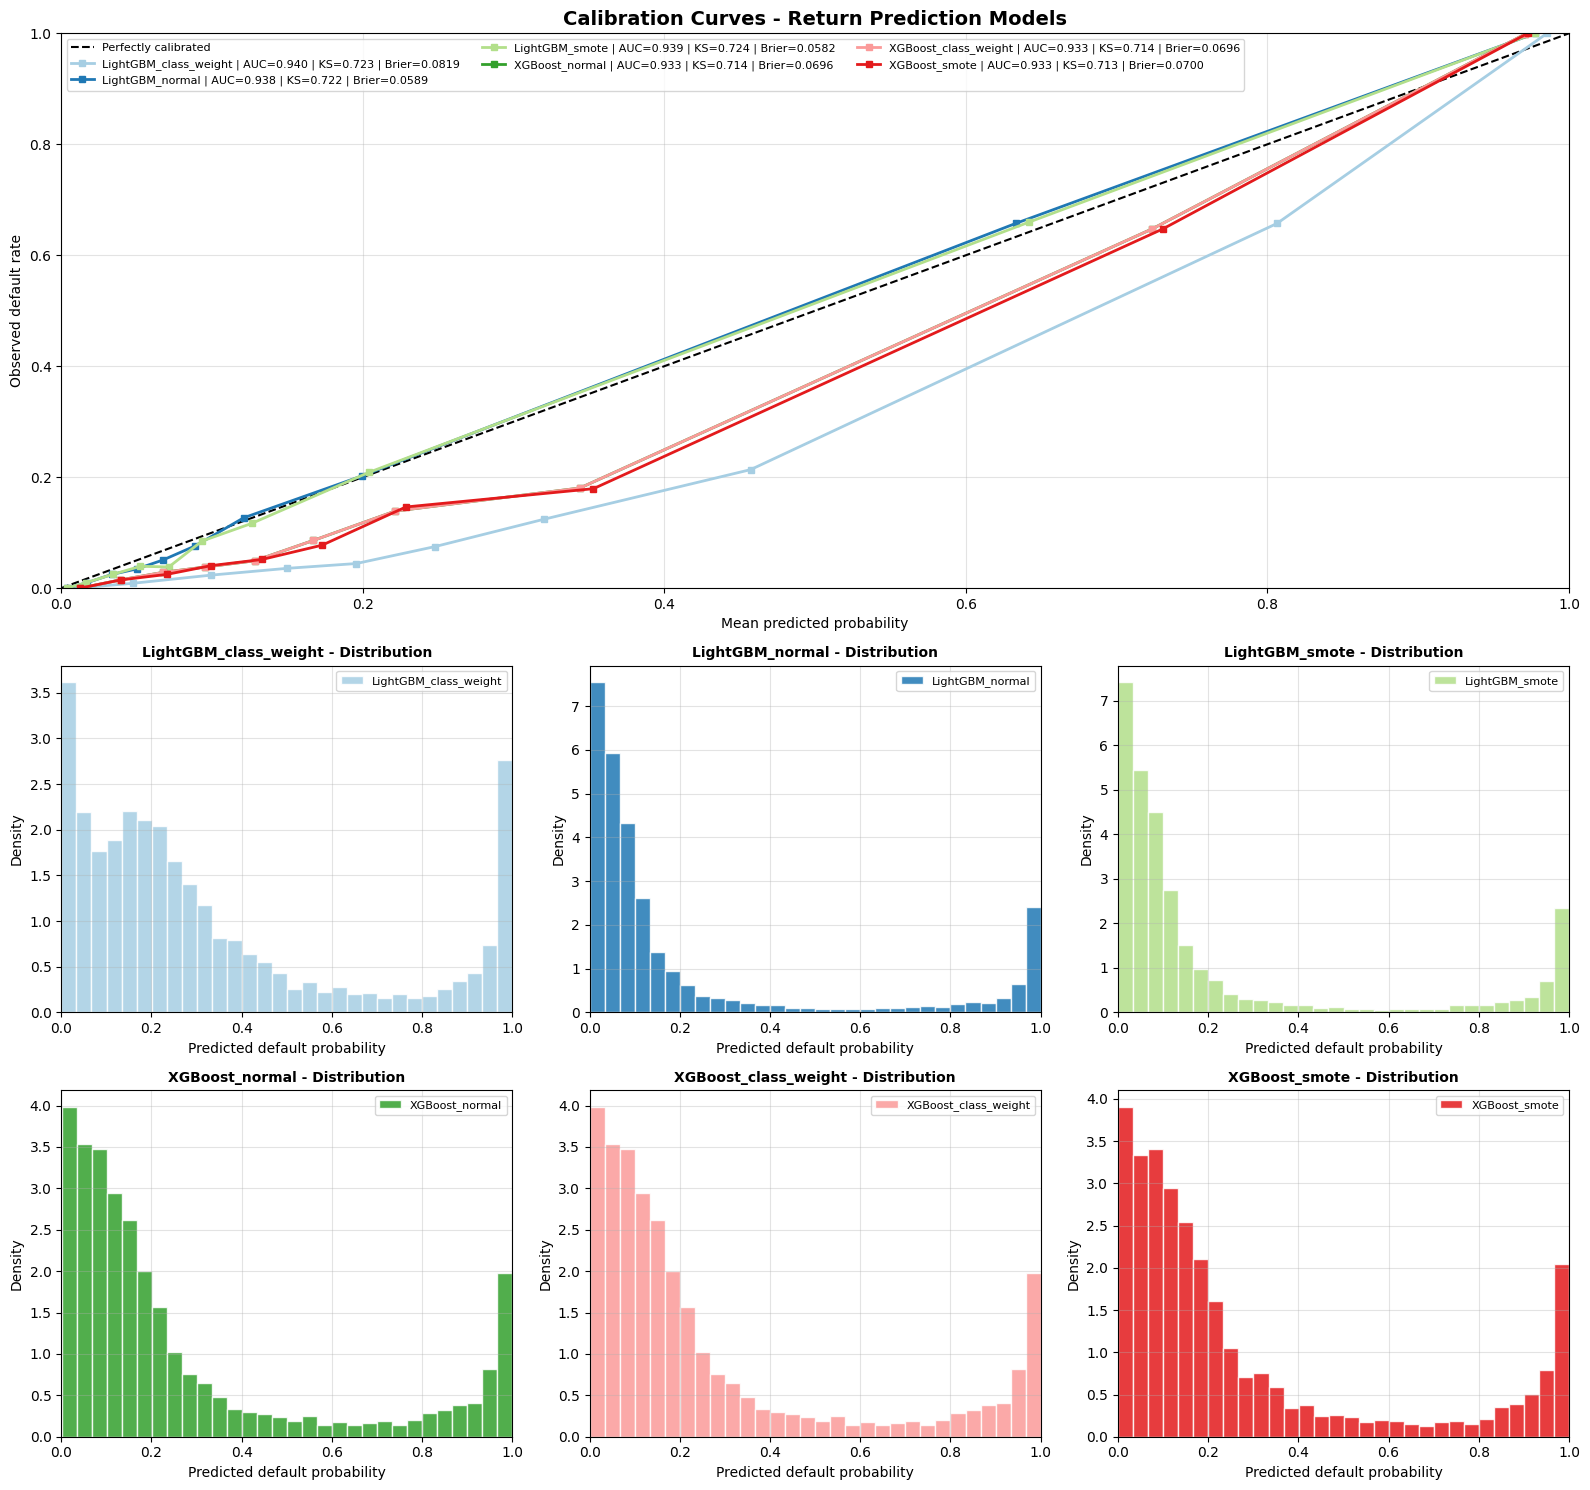

In [19]:
print("=" * 15, "CALIBRATION CURVES & PROBABILITY DISTRIBUTIONS", "=" * 15)

# Take top N model from ranking_score
TOP_N = 6

top_models_data = (results_df.sort_values("ranking_score", ascending=False).head(TOP_N))
model_names = [
    f"{row.model}_{row.imbalance_data}"
    for _, row in top_models_data.iterrows()]

n_models = len(model_names)
n_cols = 3
n_hist_rows = math.ceil(n_models / n_cols)

fig = plt.figure(figsize=(16, 5 + 5 * n_hist_rows))

gs = fig.add_gridspec(nrows=n_hist_rows + 1, ncols=n_cols, height_ratios=[1.6] + [1] * n_hist_rows)
colors = plt.get_cmap("Paired")

# 1. Calibration curve
ax_calib = fig.add_subplot(gs[0, :])
ax_calib.plot([0, 1], [0, 1], linestyle="--", color="black",
              linewidth=1.5, label="Perfectly calibrated")

for idx, (_, row) in enumerate(top_models_data.iterrows()):
    name = f"{row.model}_{row.imbalance_data}"
    y_prob = all_probs[name]
    prob_true, prob_pred = calibration_curve(
        y_test,
        y_prob,
        n_bins=10,
        strategy="quantile")

    brier = brier_score_loss(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ks = max(roc_curve(y_test, y_prob)[1] - roc_curve(y_test, y_prob)[0])

    ax_calib.plot(prob_pred, prob_true, marker="s", markersize=5,
                linewidth=2, color=colors(idx),
                label=f"{name} | AUC={auc:.3f} | KS={ks:.3f} | Brier={brier:.4f}")

ax_calib.set_title("Calibration Curves - Return Prediction Models", fontsize=14, weight="bold")
ax_calib.set_xlabel("Mean predicted probability")
ax_calib.set_ylabel("Observed default rate")
ax_calib.set_xlim(0, 1)
ax_calib.set_ylim(0, 1)
ax_calib.grid(True, alpha=0.35)
ax_calib.legend(fontsize=8, ncol=3, loc="upper left")

# 2. Probability histograms
for i, (_, row) in enumerate(top_models_data.iterrows()):
    r = (i // n_cols) + 1
    c = i % n_cols

    ax = fig.add_subplot(gs[r, c])
    name = f"{row.model}_{row.imbalance_data}"
    y_prob = all_probs[name]

    ax.hist(y_prob, bins=30, density=True, alpha=0.85,
            color=colors(i), edgecolor="white", label=name)
    ax.set_title(f"{name} - Distribution", fontsize=10, weight="bold")
    ax.set_xlabel("Predicted default probability")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=8)

# Hide empty subplots
total_slots = n_hist_rows * n_cols
for j in range(n_models, total_slots):
    r = (j // n_cols) + 1
    c = j % n_cols
    ax = fig.add_subplot(gs[r, c])
    ax.axis("off")

plt.tight_layout()
plt.show()

=============== RISK GROUP CLASSIFICATIONS ===============

Best model: LightGBM (class_weight)
Test AUC: 0.9395


,risk_group,count,min_score,max_score,avg_score,bad_count,bad_rate,population_pct,bad_capture_pct,lift
3,Very High Risk,815,0.9578,0.9999,0.9855,815,1.0000,10.0,45.86,4.58
0,High Risk,1629,0.3724,0.9577,0.6316,709,0.4352,20.0,39.90,2.00
2,Medium Risk,1629,0.2199,0.3723,0.2840,162,0.0994,20.0,9.12,0.46
1,Low Risk,1629,0.1265,0.2198,0.1727,65,0.0399,20.0,3.66,0.18
4,Very Low Risk,2444,0.0004,0.1265,0.0523,26,0.0106,30.0,1.46,0.05


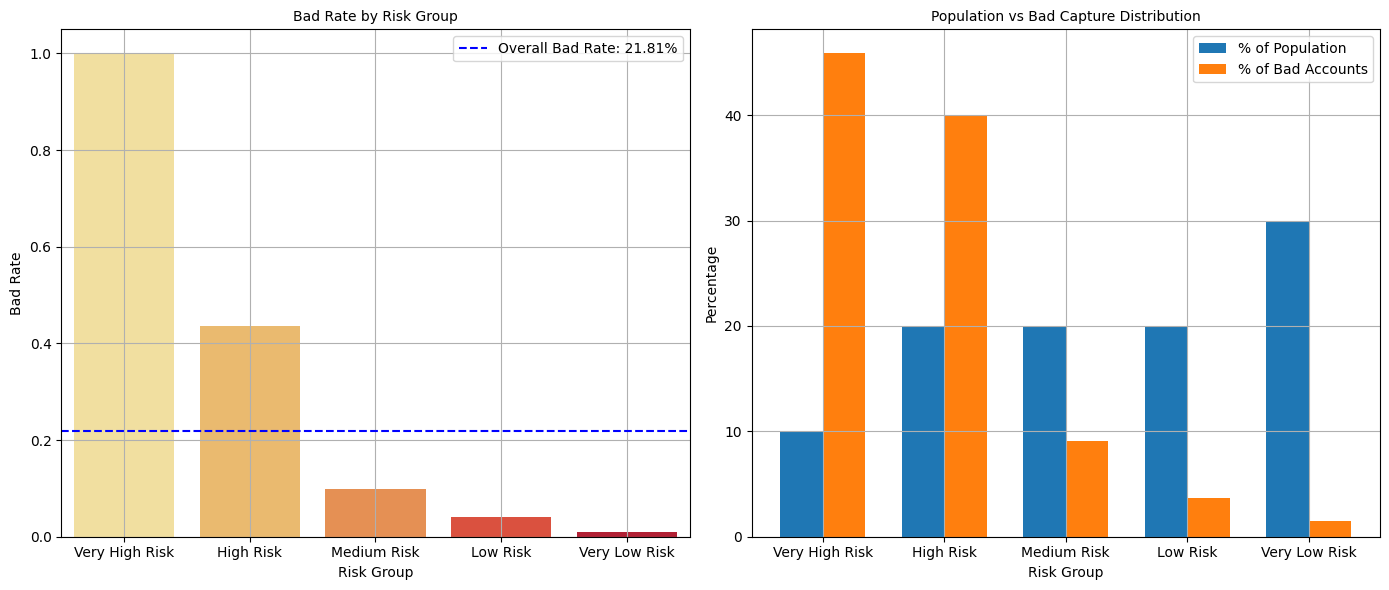

In [20]:
print("=" * 15, "RISK GROUP CLASSIFICATIONS", "=" * 15)
# 1. Select best model (based on TEST AUC)
best_model_info = results_df.sort_values("roc_auc", ascending=False).iloc[0]

best_model_name = best_model_info["model"]
best_imbalance = best_model_info["imbalance_data"]

print(f"\nBest model: {best_model_name} ({best_imbalance})")
print(f"Test AUC: {best_model_info['roc_auc']:.4f}")

# 2. Get predicted probabilities of best model
model_key = f"{best_model_name}_{best_imbalance}"

df_scores = pd.DataFrame({
    "score": all_probs[model_key],   # probability from best model
    "y_true": y_test})

# Overall bad rate
overall_bad_rate = df_scores["y_true"].mean()

# 3. Create deciles (1 = lowest risk, 10 = highest risk)
df_scores["decile"] = pd.qcut(
    df_scores["score"], 10,
    labels=range(1,11),
    duplicates="drop").astype(int)

# 4. Map decile → risk groups
def map_decile_to_group(d):
    if d == 10:
        return "Very High Risk"
    elif d in [8,9]:
        return "High Risk"
    elif d in [6,7]:
        return "Medium Risk"
    elif d in [4,5]:
        return "Low Risk"
    else:
        return "Very Low Risk"

df_scores["risk_group"] = df_scores["decile"].apply(map_decile_to_group)

# 5. Risk group statistics
risk_group_analysis = df_scores.groupby("risk_group").agg(
    count=("score","size"),
    min_score=("score","min"),
    max_score=("score","max"),
    avg_score=("score","mean"),
    bad_count=("y_true","sum"),
    bad_rate=("y_true","mean")).reset_index()

# 6. Additional metrics
risk_group_analysis["population_pct"] = (
    risk_group_analysis["count"] / len(df_scores) * 100).round(2)

risk_group_analysis["bad_capture_pct"] = (
    risk_group_analysis["bad_count"] /
    risk_group_analysis["bad_count"].sum() * 100).round(2)

risk_group_analysis["lift"] = (
    risk_group_analysis["bad_rate"] /
    overall_bad_rate).round(2)

# 7. Order risk groups
risk_order = ["Very High Risk","High Risk","Medium Risk","Low Risk","Very Low Risk"]

risk_group_analysis["risk_group"] = pd.Categorical(
    risk_group_analysis["risk_group"],
    categories=risk_order,
    ordered=True)

risk_group_analysis = risk_group_analysis.sort_values("risk_group")

display(risk_group_analysis.round(4))

# 8. Visualization
plt.figure(figsize=(14,6))

# Bad rate plot
plt.subplot(1,2,1)
sns.barplot(x="risk_group", y="bad_rate", data=risk_group_analysis, palette="YlOrRd")
plt.axhline(y=overall_bad_rate,color="blue",linestyle="--",label=f"Overall Bad Rate: {overall_bad_rate:.2%}")
plt.title("Bad Rate by Risk Group", fontsize = 10)
plt.xlabel("Risk Group")
plt.ylabel("Bad Rate")
plt.legend()
plt.grid()

# Population vs bad capture
plt.subplot(1,2,2)

x = np.arange(len(risk_group_analysis))
width = 0.35
plt.bar(x - width/2,risk_group_analysis["population_pct"],width,label="% of Population")
plt.bar(x + width/2,risk_group_analysis["bad_capture_pct"],width,label="% of Bad Accounts")

plt.xticks(x, risk_group_analysis["risk_group"])
plt.title("Population vs Bad Capture Distribution", fontsize = 10)
plt.xlabel("Risk Group")
plt.ylabel("Percentage")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

=============== MODEL INTERPRETATION AND FEATURE IMPORTANCE ANALYSIS ===============

Analyzing: LightGBM_class_weight
                               feature  importance
12       num__credit_utilization_ratio         111
10           num__debt_to_income_ratio         115
25    cat__loan_intent_HOMEIMPROVEMENT         116
15                num__monthly_payment         119
28            cat__loan_intent_VENTURE         120
26            cat__loan_intent_MEDICAL         121
23  cat__loan_intent_DEBTCONSOLIDATION         123
0                      num__person_age         141
17              num__credit_risk_ratio         146
33                   cat__loan_grade_E         156
22     cat__person_home_ownership_RENT         160
32                   cat__loan_grade_D         170
21      cat__person_home_ownership_OWN         206
3                       num__loan_amnt         207
2               num__person_emp_length         214
18                num__income_loan_gap         257
14            

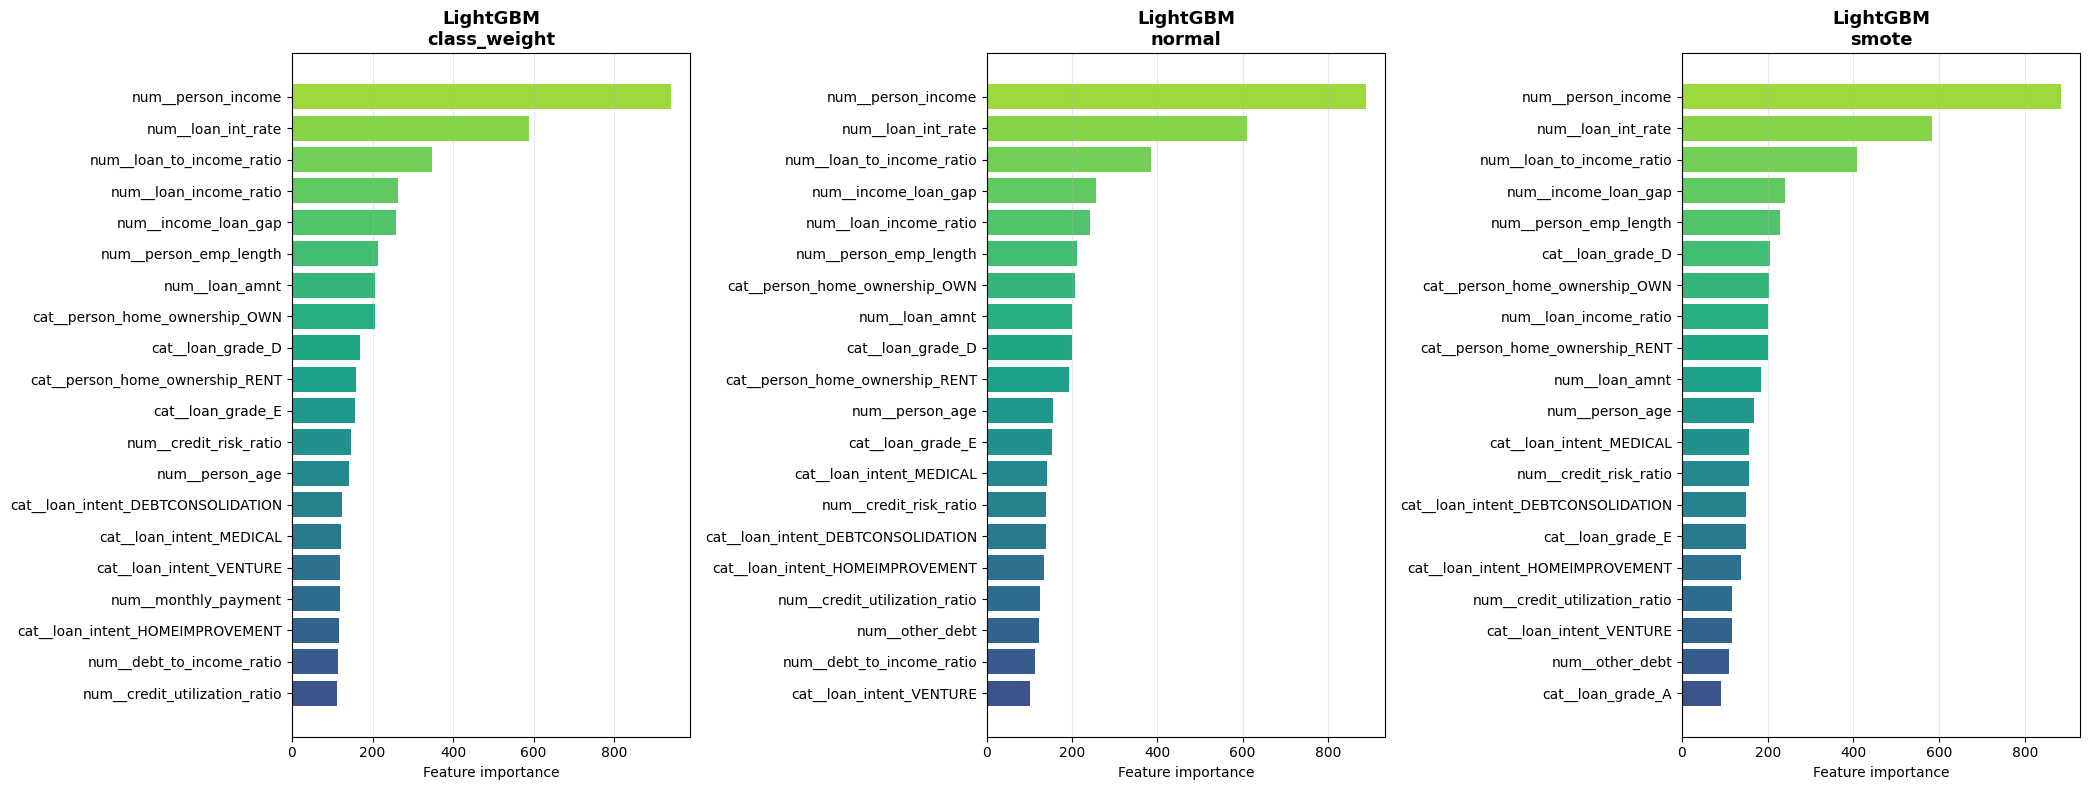

In [21]:
print("=" * 15, "MODEL INTERPRETATION AND FEATURE IMPORTANCE ANALYSIS", "=" * 15)

from sklearn.inspection import permutation_importance

# Top 3 models by ranking score
top_models = (results_df.sort_values("ranking_score", ascending=False).head(3))
fig, axes = plt.subplots(1, len(top_models), figsize=(7 * len(top_models), 8))

if len(top_models) == 1:
    axes = [axes]

for idx, (_, row) in enumerate(top_models.iterrows()):
    model_name = row["model"]
    imbalance_type = row["imbalance_data"]

    print(f"\nAnalyzing: {model_name}_{imbalance_type}")
    try:
        # Map display model name back to function model_type
        if model_name == "Logistic Regression":
            model_type = "logistic"
        elif model_name == "Random Forest":
            model_type = "random_forest"
        elif model_name == "MLP Neural Network":
            model_type = "mlp"
        elif model_name == "XGBoost":
            model_type = "xgboost"
        elif model_name == "LightGBM":
            model_type = "lightgbm"
        else:
            print(f"Unknown model name: {model_name}")
            continue

        # Recreate and refit pipeline
        pipeline, fitted_model_name = create_credit_model(
            model_type=model_type,
            imbalance_strategy=imbalance_type)
        pipeline.fit(x_train, y_train)

        preprocessor = pipeline.named_steps["preprocessor"]
        classifier = pipeline.named_steps["classifier"]

        # Get transformed feature names
        try:
            feature_names = preprocessor.get_feature_names_out()
        except Exception:
            feature_names = np.array([f"feature_{i}" for i in range(preprocessor.transform(x_train.head(1)).shape[1])])

        # Transform X for model-level importance
        X_test_transformed = preprocessor.transform(x_test)

        # Case 1: Logistic Regression coefficients
        if model_type == "logistic":
            importance = np.abs(classifier.coef_[0])

        # Case 2: Tree-based models
        elif hasattr(classifier, "feature_importances_"):
            importance = classifier.feature_importances_

        # Case 3: MLP / models without native importance
        else:
            print("Using permutation importance for model without native feature importance...")

            perm_result = permutation_importance(
                pipeline,
                x_test,
                y_test,
                scoring="roc_auc",
                n_repeats=5,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            feature_names = np.array(x_test.columns)
            importance = perm_result.importances_mean

        # Build top importance table
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importance})

        importance_df = (
            importance_df
            .sort_values("importance", ascending=False)
            .head(20)
            .sort_values("importance", ascending=True))
        print(importance_df)

        # Plot
        axes[idx].barh(
            importance_df["feature"],
            importance_df["importance"],
            color=plt.get_cmap("viridis")(np.linspace(0.25, 0.85, len(importance_df))))

        axes[idx].set_title(
            f"{model_name}\n{imbalance_type}",
            fontsize=13,
            weight="bold")
        axes[idx].set_xlabel("Feature importance")
        axes[idx].grid(axis="x", alpha=0.3)

    except Exception as e:
        print(f"{model_name}_{imbalance_type}: {e}")
        axes[idx].axis("off")

plt.tight_layout()
plt.show()